In [1]:
### import
import os
os.add_dll_directory('C:/Users/jonstingel/opensim-core-4.5.1-2024-08-23-cf3ef35/bin')
import opensim as osim

datadir = 'G:\Shared drives\HPL_Drive\JonExotendon'
currentdir = datadir
conditions = ['short-stiff', 'original-medium', 'long-stiff', 'long-compliant']
cond_colors = {'short-stiff': 'red', 'original-medium': 'blue', 'long-stiff': 'green', 'long-compliant': 'purple'}


In [18]:
experimentDistances = {}
experimentalTimes = {}
# loop through and get all the TRC files to get the lengths between markers. 
listsubjectdirs = os.listdir(datadir)
for subjectdir in listsubjectdirs:
    print(subjectdir)
    currentdir = os.path.join(datadir,subjectdir)
    listsubjectfiles = os.listdir(currentdir)
    for subjectfile in listsubjectfiles:
        if subjectfile.endswith('.trc') and 'static' not in subjectfile.lower() and 'trimmed_trimmed' in subjectfile.lower():
            print(f"Processing file: {subjectfile}")
            
            # figure out the short name of the trial
            # import pdb; pdb.set_trace()
            trial_name = subjectfile.split('_')[2].split('.')[0]
            if 'EPS9' in currentdir: 
                trial_name = trial_name.split('-')[0]
            if subjectdir == 'EPS1' or subjectdir == 'EPS3' or subjectdir == 'EPS4' or subjectdir == 'EPS6':
                trial_name = trial_name[:-1]
            else:
                trial_name = trial_name[:-2]
            print(f"  {trial_name.lower()}")
            # we have a movement trial and we want to get the length between the markers
            trcfile = os.path.join(currentdir,subjectfile)
            trc = osim.TimeSeriesTableVec3(trcfile)
            trcflat = trc.flatten()
            time = trc.getIndependentColumn()
            print(time[0], time[-1])
            rightFootx = trcflat.getDependentColumn('r_band_shoe_1').to_numpy()
            rightFooty = trcflat.getDependentColumn('r_band_shoe_2').to_numpy()
            rightFootz = trcflat.getDependentColumn('r_band_shoe_3').to_numpy()
            leftFootx = trcflat.getDependentColumn('L_band_shoe_1').to_numpy()
            leftFooty = trcflat.getDependentColumn('L_band_shoe_2').to_numpy()
            leftFootz = trcflat.getDependentColumn('L_band_shoe_3').to_numpy()
            # compute the distance between the two markers throughout time
            distance = ((rightFootx - leftFootx)**2 + (rightFooty - leftFooty)**2 + (rightFootz - leftFootz)**2)**0.5
            # import matplotlib.pyplot as plt
            # plt.plot(time,distance)
            # import pdb; pdb.set_trace()
            experimentDistances[subjectdir + '_' + trial_name.lower()] = distance
            experimentalTimes[subjectdir + '_' + trial_name.lower()] = time

EPS1
Processing file: Trimmed_Trimmed_bad1.trc
  bad
0.0 10.0
Processing file: Trimmed_Trimmed_Natural1.trc
  natural
0.0 10.0
Processing file: Trimmed_Trimmed_Optimal1.trc
  optimal
0.0 10.0
Processing file: Trimmed_Trimmed_Original1.trc
  original
0.0 5.0
Processing file: Trimmed_Trimmed_placebo1.trc
  placebo
0.0 5.0
EPS6
Processing file: Trimmed_Trimmed_bad1.trc
  bad
0.0 10.0
Processing file: Trimmed_Trimmed_Natural1.trc
  natural
0.0 10.0
Processing file: Trimmed_Trimmed_Optimal1.trc
  optimal
0.0 10.0
Processing file: Trimmed_Trimmed_Original1.trc
  original
0.0 9.995
Processing file: Trimmed_Trimmed_placebo1.trc
  placebo
0.0 10.0
EPS3
Processing file: Trimmed_Trimmed_bad1.trc
  bad
0.0 10.0
Processing file: Trimmed_Trimmed_Natural2.trc
  natural
0.0 10.0
Processing file: Trimmed_Trimmed_Optimal1.trc
  optimal
0.0 6.75
Processing file: Trimmed_Trimmed_Original1.trc
  original
0.0 10.0
Processing file: Trimmed_Trimmed_placebo1.trc
  placebo
0.0 10.0
EPS4
Processing file: Trimmed

In [3]:
print(f"Number of trials: {len(experimentDistances)}")
for k, v in experimentDistances.items():
    print(f"{k}: shape={v.shape}, dtype={v.dtype}")

Number of trials: 55
EPS1_bad: shape=(2001,), dtype=float64
EPS1_natural: shape=(2001,), dtype=float64
EPS1_optimal: shape=(2001,), dtype=float64
EPS1_original: shape=(1001,), dtype=float64
EPS1_placebo: shape=(1001,), dtype=float64
EPS6_bad: shape=(2001,), dtype=float64
EPS6_natural: shape=(2001,), dtype=float64
EPS6_optimal: shape=(2001,), dtype=float64
EPS6_original: shape=(2000,), dtype=float64
EPS6_placebo: shape=(2001,), dtype=float64
EPS3_bad: shape=(2001,), dtype=float64
EPS3_natural: shape=(2001,), dtype=float64
EPS3_optimal: shape=(1351,), dtype=float64
EPS3_original: shape=(2001,), dtype=float64
EPS3_placebo: shape=(2001,), dtype=float64
EPS4_bad: shape=(2001,), dtype=float64
EPS4_natural: shape=(2001,), dtype=float64
EPS4_optimal: shape=(2001,), dtype=float64
EPS4_original: shape=(2001,), dtype=float64
EPS4_placebo: shape=(2001,), dtype=float64
EPS8_bad: shape=(2001,), dtype=float64
EPS8_natural: shape=(2001,), dtype=float64
EPS8_optimal: shape=(2001,), dtype=float64
EPS8_o

In [ ]:
## explore the time durations of the different conditions on average and the percent changes between them. 


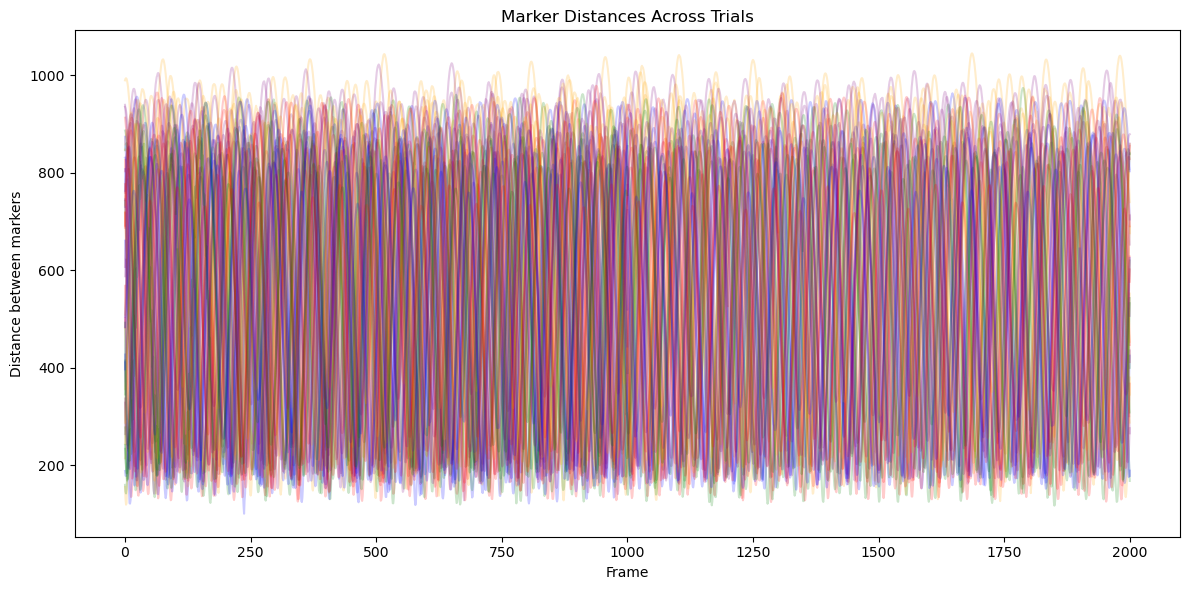

In [4]:
import matplotlib.pyplot as plt
color_map = {
    'bad': 'red',
    'original': 'blue',
    'optimal': 'green',
    'placebo': 'purple',
    'natural': 'orange'
}

def get_color(trial_name):
    for key, color in color_map.items():
        if key in trial_name:
            return color
    return 'gray'

plt.figure(figsize=(12, 6))
for trial_name, distance in experimentDistances.items():
    plt.plot(distance, label=trial_name, color=get_color(trial_name), alpha=0.2)
plt.xlabel('Frame')
plt.ylabel('Distance between markers')
plt.title('Marker Distances Across Trials')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [25]:
from scipy.signal import find_peaks
import numpy as np

# want to store some data about cadence somehow
cadences = {}

# create individual gait cycles. 
# Segment each trial's distance trajectory into cycles using every-other peak
trial_cycles = {}

min_peak_height = 700
min_peak_distance = 30  # adjust as needed for your data

for trial_name, distance in experimentDistances.items():
    # Find peaks in the distance data
    peaks, _ = find_peaks(distance, height=min_peak_height, distance=min_peak_distance)
    cycles = []
    # Step through peaks in steps of 2 (every-other peak)
    for i in range(0, len(peaks) - 2, 2):
        start_idx = peaks[i]
        mid_idx = peaks[i + 1]
        end_idx = peaks[i + 2]
        cycle_distance = distance[start_idx:end_idx + 1]
        cycles.append({
            'start_idx': int(start_idx),
            'mid_idx': int(mid_idx),
            'end_idx': int(end_idx),
            'cycle_distance': np.asarray(cycle_distance, dtype=float),
            'time': np.asarray(experimentalTimes[trial_name][start_idx:end_idx + 1], dtype=float)
        })
    trial_cycles[trial_name] = cycles
    time = experimentalTimes[trial_name]
    # Estimate cadence (steps per minute)
    if len(peaks) > 1:
        # find the total time from first peak to the last
        time_between_all_peaks = time[peaks[-1]] - time[peaks[0]]
        num_steps = len(peaks) - 1  # number of steps is number of peaks - 1
        steps_per_minute = (num_steps / time_between_all_peaks) * 60
        
        
        
        # time_between_all_peaks = (peaks[-1] - peaks[0]) * (1/2000)  # assuming 100 Hz sampling rate
        # num_steps = len(peaks) - 1  # number of steps is number of peaks - 1
        # steps_per_minute = (num_steps / time_between_all_peaks) * 60
        cadences[trial_name] = steps_per_minute
        # print(time_between_all_peaks)
        # print(num_steps)
        # print(steps_per_minute)


print(cadences)

# # # Plot each trial with segmented cycles in different colors and show the peaks used for segmentation
# import matplotlib.pyplot as plt

# for trial_name, distance in experimentDistances.items():
#     cycles = trial_cycles[trial_name]
#     # Find peaks again to plot them (using the same parameters as above)
#     peaks, _ = find_peaks(distance, height=min_peak_height, distance=min_peak_distance)
#     plt.figure(figsize=(12, 4))
#     plt.title(f"Segmented Cycles for {trial_name}")
#     plt.xlabel("Frame")
#     plt.ylabel("Distance")
#     # Plot the full trajectory in light gray
#     plt.plot(distance, color='lightgray', label='Full trajectory')
#     # Plot each cycle in a different color
#     for idx, cycle in enumerate(cycles):
#         color = plt.cm.tab20(idx % 20)
#         x = np.arange(cycle['start_idx'], cycle['end_idx'] + 1)
#         plt.plot(x, cycle['cycle_distance'], color=color, linewidth=2, label=f'Cycle {idx+1}')
#     # Plot the peaks used for segmentation
#     plt.scatter(peaks, distance[peaks], color='black', s=40, zorder=3, label='Peaks')
#     plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
#     plt.tight_layout()
#     # plt.show()


{'EPS1_bad': 216.27188465499484, 'EPS1_natural': 192.94605809128635, 'EPS1_optimal': 215.93830334190233, 'EPS1_original': 211.45374449339207, 'EPS1_placebo': 194.38444924406048, 'EPS6_bad': 181.9100555836281, 'EPS6_natural': 170.8860759493671, 'EPS6_optimal': 184.51749734888654, 'EPS6_original': 183.57980622131566, 'EPS6_placebo': 171.0794297352342, 'EPS3_bad': 197.12525667351127, 'EPS3_natural': 184.23746161719546, 'EPS3_optimal': 198.49624060150376, 'EPS3_original': 195.17313746065057, 'EPS3_placebo': 182.5813221406086, 'EPS4_bad': 190.17432646592707, 'EPS4_natural': 169.98950682056665, 'EPS4_optimal': 197.42930591259642, 'EPS4_original': 193.04618578100676, 'EPS4_placebo': 174.09326424870466, 'EPS8_bad': 216.49484536082474, 'EPS8_natural': 195.1219512195122, 'EPS8_optimal': 211.94805194805193, 'EPS8_original': 213.74045801526714, 'EPS8_placebo': 198.04022692109334, 'EPS7_bad': 204.25531914893617, 'EPS7_natural': 190.07391763463568, 'EPS7_optimal': 206.0353798126951, 'EPS7_original':

In [ ]:
## explore the differences in stride duration... 


You’re right — I only drafted it, not inserted into your notebook JSON.

Paste the following **4 new code cells** directly under:

`## explore the differences in stride duration...`

#### Cell 1 — subject x condition mean stride duration


In [26]:
import numpy as np
import pandas as pd
from collections import defaultdict

# Canonical condition names + aliases used in your trial names
condition_aliases = {
    'bad': ['bad', 'short-stiff'],
    'natural': ['natural'],
    'original': ['original', 'original-medium'],
    'optimal': ['optimal', 'long-stiff'],
    'placebo': ['placebo', 'long-compliant'],
}

def parse_subject_condition(trial_name: str):
    tn = trial_name.lower()
    subject = trial_name.split('_')[0]
    cond = None
    for canon, aliases in condition_aliases.items():
        if any(a in tn for a in aliases):
            cond = canon
            break
    return subject, cond

# 1) collect stride durations by subject/condition
subject_condition_stride_durations = defaultdict(lambda: defaultdict(list))
issues = []

for trial_name, cycles in trial_cycles.items():
    subj, cond = parse_subject_condition(trial_name)
    if cond is None:
        issues.append((trial_name, "unrecognized condition"))
        continue

    for cyc in cycles:
        dur = None

        # preferred: cycle-local time vector
        t = cyc.get('time', None)
        if t is not None and len(t) >= 2:
            dur = float(t[-1] - t[0])

        # fallback: global time + indices
        if (dur is None or not np.isfinite(dur)) and trial_name in experimentalTimes:
            s = cyc.get('start_idx', None)
            e = cyc.get('end_idx', None)
            if s is not None and e is not None and e > s:
                tg = experimentalTimes[trial_name]
                dur = float(tg[e] - tg[s])

        if dur is None or (not np.isfinite(dur)) or dur <= 0:
            issues.append((trial_name, f"invalid duration {dur}"))
            continue

        subject_condition_stride_durations[subj][cond].append(dur)

# 2) aggregate stats
subject_stride_duration_stats = {}
for subj, cond_dict in subject_condition_stride_durations.items():
    subject_stride_duration_stats[subj] = {}
    for cond, vals in cond_dict.items():
        arr = np.asarray(vals, dtype=float)
        subject_stride_duration_stats[subj][cond] = {
            'mean_s': float(np.mean(arr)),
            'std_s': float(np.std(arr, ddof=1)) if arr.size > 1 else 0.0,
            'n_strides': int(arr.size),
        }

# 3) tidy table
rows = []
for subj, conds in subject_stride_duration_stats.items():
    for cond, s in conds.items():
        rows.append([subj, cond, s['mean_s'], s['std_s'], s['n_strides']])

stride_stats_df = pd.DataFrame(
    rows, columns=['subject', 'condition', 'mean_stride_s', 'std_stride_s', 'n_strides']
).sort_values(['subject', 'condition']).reset_index(drop=True)

print(f"Subjects with stride stats: {len(subject_stride_duration_stats)}")
print(f"Skipped rows/issues: {len(issues)}")
if issues:
    print("First 10 issues:", issues[:10])

display(stride_stats_df)

Subjects with stride stats: 11
Skipped rows/issues: 0


,subject,condition,mean_stride_s,std_stride_s,n_strides
0,EPS1,bad,0.554706,0.007597,17
1,EPS1,natural,0.622000,0.008824,15
2,EPS1,optimal,0.555588,0.012360,17
3,EPS1,original,0.567500,0.004629,8
4,EPS1,placebo,0.619286,0.008381,7
5,EPS10,bad,0.617188,0.005154,16
6,EPS10,natural,0.652667,0.005300,15
7,EPS10,optimal,0.625333,0.004419,15
8,EPS10,original,0.624333,0.005627,15
9,EPS10,placebo,0.648000,0.004551,15


Perfect—add this as a **new code cell** right after your stride-duration summary cells.





If you want, I can also make the highlighted points use a black outline so they stand out even more without changing color.



If you want, I can also give a **paired-line plot by subject** (natural-referenced) to show within-subject condition shifts directly.



#### Cell 2 — percent change vs natural (per subject)


In [27]:
target_conditions = ['bad', 'optimal', 'original', 'placebo']

subject_stride_pct_change_from_natural = {}
missing_natural = []
missing_pairs = []

for subj, conds in subject_stride_duration_stats.items():
    nat = conds.get('natural', {}).get('mean_s', None)
    if nat is None or nat <= 0:
        missing_natural.append(subj)
        continue

    subject_stride_pct_change_from_natural[subj] = {}
    for cond in target_conditions:
        cmean = conds.get(cond, {}).get('mean_s', None)
        if cmean is None:
            missing_pairs.append((subj, cond))
            continue
        pct = 100.0 * (cmean - nat) / nat
        subject_stride_pct_change_from_natural[subj][cond] = float(pct)

pct_rows = []
for subj, d in subject_stride_pct_change_from_natural.items():
    for cond, pct in d.items():
        pct_rows.append([subj, cond, pct])

stride_pct_df = pd.DataFrame(
    pct_rows, columns=['subject', 'condition', 'pct_change_vs_natural']
).sort_values(['condition', 'subject']).reset_index(drop=True)

print("Subjects missing natural:", missing_natural)
print("Missing subject-condition comparisons (first 20):", missing_pairs[:20])

display(stride_pct_df)

Subjects missing natural: []
Missing subject-condition comparisons (first 20): []


,subject,condition,pct_change_vs_natural
0,EPS1,bad,-10.818990
1,EPS10,bad,-5.436032
2,EPS11,bad,-8.458943
3,EPS12,bad,-6.967257
4,EPS13,bad,-17.456844
5,EPS3,bad,-6.537871
6,EPS4,bad,-10.691345
7,EPS6,bad,-6.225624
8,EPS7,bad,-7.062147
9,EPS8,bad,-9.899570


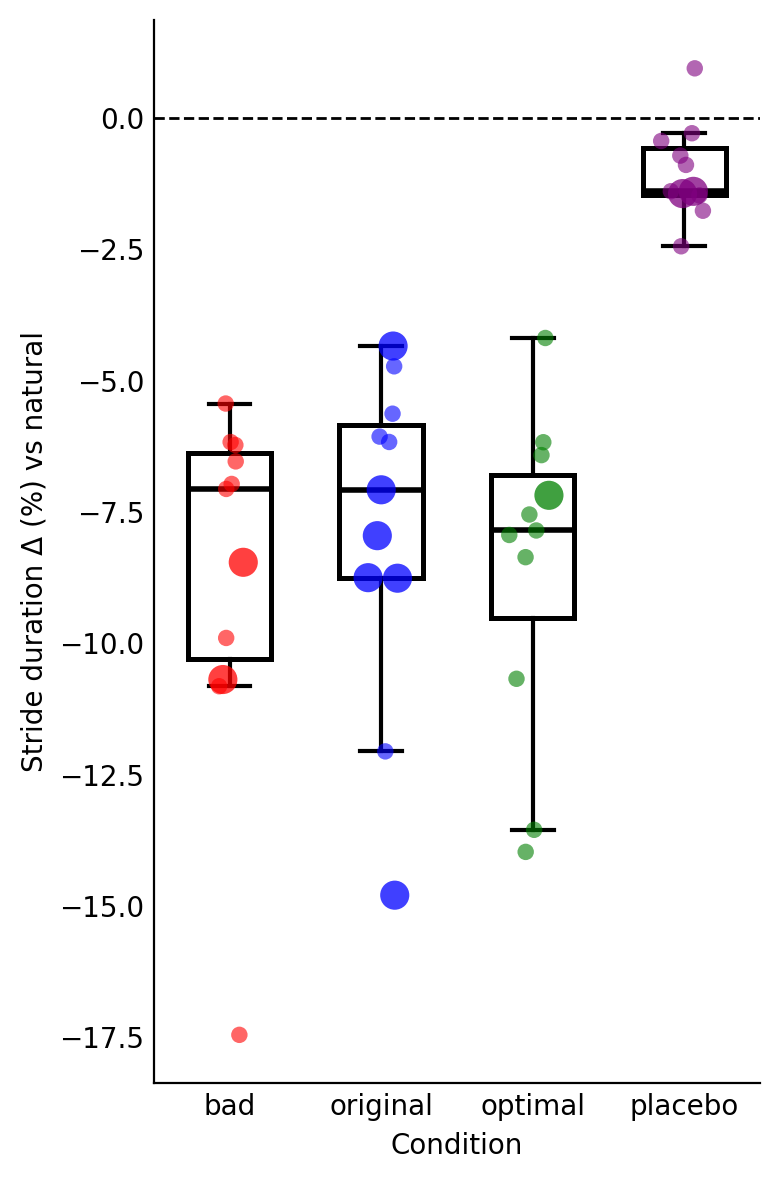

In [ ]:
# Box + jitter plot: % stride-duration change vs natural by condition
# with manually highlighted (larger) subject-condition points

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

order = ['bad', 'original', 'optimal', 'placebo']

# Subject-condition points to enlarge
highlight_points = {
    ('EPS1', 'original'),
    ('EPS3', 'optimal'),
    ('EPS4', 'bad'),
    ('EPS6', 'original'),
    ('EPS7', 'original'),
    ('EPS8', 'original'),
    ('EPS9', 'placebo'),
    ('EPS10', 'original'),
    ('EPS11', 'bad'),
    ('EPS12', 'placebo'),
    ('EPS13', 'original'),
}

# Build tidy rows: [{subject, condition, value}, ...]
rows = []
if 'stride_pct_df' in globals() and not stride_pct_df.empty:
    for _, r in stride_pct_df.iterrows():
        subj = str(r['subject']).upper()
        cond = str(r['condition']).lower()
        val = float(r['pct_change_vs_natural'])
        if cond in order and np.isfinite(val):
            rows.append({'subject': subj, 'condition': cond, 'value': val})
else:
    for subj, d in subject_stride_pct_change_from_natural.items():
        for cond in order:
            if cond in d and np.isfinite(d[cond]):
                rows.append({'subject': str(subj).upper(), 'condition': cond, 'value': float(d[cond])})

# Group for boxplot
delta_groups = defaultdict(list)
for r in rows:
    delta_groups[r['condition']].append(r['value'])

plot_colors = {'bad': 'red', 'original': 'blue', 'optimal': 'green', 'placebo': 'purple'}
data = [delta_groups[c] for c in order]

fig, ax = plt.subplots(figsize=(4, 6), dpi=200)

boxprops = dict(facecolor='none', edgecolor='black', linewidth=1.8)
medianprops = dict(linewidth=2, color='black')
whiskerprops = dict(linewidth=1.5, color='black')
capprops = dict(linewidth=1.5, color='black')

ax.boxplot(
    data,
    labels=order,
    patch_artist=True,
    boxprops=boxprops,
    medianprops=medianprops,
    whiskerprops=whiskerprops,
    capprops=capprops,
    showfliers=False,
    widths=0.55,
    zorder=1,
)

# Jittered points with manual size overrides
rng = np.random.default_rng(123)
normal_s = 35
highlight_s = 110  # bigger dots

xpos = {c: i + 1 for i, c in enumerate(order)}
for r in rows:
    x = rng.normal(loc=xpos[r['condition']], scale=0.07)
    is_highlight = (r['subject'], r['condition']) in highlight_points
    ax.scatter(
        x, r['value'],
        color=plot_colors.get(r['condition'], 'gray'),
        alpha=0.75 if is_highlight else 0.6,
        s=highlight_s if is_highlight else normal_s,
        edgecolors='none',
        zorder=3 if is_highlight else 2
    )

ax.axhline(0, color='black', linewidth=1, linestyle='--', zorder=0)
ax.set_ylabel('Stride duration Δ (%) vs natural')
ax.set_xlabel('Condition')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
# plt.savefig(r'G:\Shared drives\Exotendon\predictiveSim\analysis\validationfigures\stride_duration_pct_change_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()



#### Cell 3 — across-subject condition averages of % change


In [28]:
across_subject_stats = {}

for cond in target_conditions:
    vals = [
        subject_stride_pct_change_from_natural[subj][cond]
        for subj in subject_stride_pct_change_from_natural
        if cond in subject_stride_pct_change_from_natural[subj]
    ]
    arr = np.asarray(vals, dtype=float)

    if arr.size == 0:
        across_subject_stats[cond] = {'n': 0, 'mean_pct': np.nan, 'std_pct': np.nan, 'sem_pct': np.nan, 'median_pct': np.nan}
    else:
        across_subject_stats[cond] = {
            'n': int(arr.size),
            'mean_pct': float(np.mean(arr)),
            'std_pct': float(np.std(arr, ddof=1)) if arr.size > 1 else 0.0,
            'sem_pct': float(np.std(arr, ddof=1) / np.sqrt(arr.size)) if arr.size > 1 else 0.0,
            'median_pct': float(np.median(arr)),
        }

across_df = pd.DataFrame([
    [c, s['n'], s['mean_pct'], s['std_pct'], s['sem_pct'], s['median_pct']]
    for c, s in across_subject_stats.items()
], columns=['condition', 'n_subjects', 'mean_pct', 'std_pct', 'sem_pct', 'median_pct'])

display(across_df.sort_values('condition').reset_index(drop=True))

,condition,n_subjects,mean_pct,std_pct,sem_pct,median_pct
0,bad,11,-8.702186,3.466620,1.045225,-7.062147
1,optimal,11,-8.533452,3.032348,0.914287,-7.853107
2,original,11,-7.848454,3.181927,0.959387,-7.078549
3,placebo,11,-1.026750,0.899468,0.271200,-1.393597




#### Cell 4 — descriptive summary cell


In [29]:
from IPython.display import Markdown, display

lines = []
lines.append("### Stride-duration analysis summary")
lines.append(f"- Built per-subject, per-condition stride-duration means from `trial_cycles` (units: seconds).")
lines.append(f"- Subjects with computed stats: **{len(subject_stride_duration_stats)}**.")
lines.append(f"- Invalid/skipped cycle rows: **{len(issues)}**.")
lines.append(f"- Subjects with natural baseline available: **{len(subject_stride_pct_change_from_natural)}**.")

if missing_natural:
    lines.append(f"- Missing natural baseline: {', '.join(missing_natural)}.")
if missing_pairs:
    lines.append(f"- Missing subject-condition comparisons (first 10): {missing_pairs[:10]}.")

lines.append("")
lines.append("**Across-subject mean % change in stride duration vs natural:**")
for cond in ['bad', 'optimal', 'original', 'placebo']:
    s = across_subject_stats.get(cond, None)
    if s is None or s['n'] == 0:
        lines.append(f"- {cond}: no data")
    else:
        lines.append(f"- {cond}: {s['mean_pct']:.2f}% ± {s['std_pct']:.2f}% (n={s['n']}, median={s['median_pct']:.2f}%).")

display(Markdown('\n'.join(lines)))

### Stride-duration analysis summary
- Built per-subject, per-condition stride-duration means from `trial_cycles` (units: seconds).
- Subjects with computed stats: **11**.
- Invalid/skipped cycle rows: **0**.
- Subjects with natural baseline available: **11**.

**Across-subject mean % change in stride duration vs natural:**
- bad: -8.70% ± 3.47% (n=11, median=-7.06%).
- optimal: -8.53% ± 3.03% (n=11, median=-7.85%).
- original: -7.85% ± 3.18% (n=11, median=-7.08%).
- placebo: -1.03% ± 0.90% (n=11, median=-1.39%).



If you want, I can also give a **single replacement cell** version (all steps combined) to reduce notebook clutter.

Yes — here’s a single cell that gives descriptive stats for exactly those highlighted subject-condition trials.



In [34]:
# Descriptive stats for highlighted stride-duration trials

import numpy as np
import pandas as pd

highlight_pairs = [
    ('EPS1', 'original'),
    ('EPS3', 'optimal'),
    ('EPS4', 'bad'),
    ('EPS6', 'original'),
    ('EPS7', 'original'),
    ('EPS8', 'original'),
    ('EPS9', 'placebo'),
    ('EPS10', 'original'),
    ('EPS11', 'bad'),
    ('EPS12', 'placebo'),
    ('EPS13', 'original'),
]

# Normalize case for matching
hp_df = pd.DataFrame(highlight_pairs, columns=['subject', 'condition'])
hp_df['subject'] = hp_df['subject'].str.upper()
hp_df['condition'] = hp_df['condition'].str.lower()

# --- Pull % change values (from stride_pct_df) ---
pct_df = stride_pct_df.copy()
pct_df['subject'] = pct_df['subject'].astype(str).str.upper()
pct_df['condition'] = pct_df['condition'].astype(str).str.lower()

selected_pct = hp_df.merge(
    pct_df[['subject', 'condition', 'pct_change_vs_natural']],
    on=['subject', 'condition'],
    how='left'
)

# --- Pull stride means/std/n from stride_stats_df for BOTH selected condition and natural ---
ss = stride_stats_df.copy()
ss['subject'] = ss['subject'].astype(str).str.upper()
ss['condition'] = ss['condition'].astype(str).str.lower()

sel_cond_stats = hp_df.merge(
    ss[['subject', 'condition', 'mean_stride_s', 'std_stride_s', 'n_strides']],
    on=['subject', 'condition'],
    how='left'
).rename(columns={
    'mean_stride_s': 'cond_mean_s',
    'std_stride_s': 'cond_std_s',
    'n_strides': 'cond_n_strides'
})

nat_stats = (
    ss.loc[ss['condition'] == 'natural', ['subject', 'mean_stride_s', 'std_stride_s', 'n_strides']]
      .rename(columns={
          'mean_stride_s': 'natural_mean_s',
          'std_stride_s': 'natural_std_s',
          'n_strides': 'natural_n_strides'
      })
)

selected_full = (
    selected_pct
    .merge(sel_cond_stats, on=['subject', 'condition'], how='left')
    .merge(nat_stats, on='subject', how='left')
)

selected_full['abs_change_s'] = selected_full['cond_mean_s'] - selected_full['natural_mean_s']

print("Highlighted trials (subject-condition level):")
display(selected_full.sort_values(['condition', 'subject']).reset_index(drop=True))

# --- Descriptive stats for highlighted % change values ---
vals = selected_full['pct_change_vs_natural'].dropna().to_numpy(dtype=float)

if vals.size == 0:
    print("No valid highlighted % change values found.")
else:
    overall_desc = pd.DataFrame([{
        'n': int(vals.size),
        'mean_pct': float(np.mean(vals)),
        'std_pct': float(np.std(vals, ddof=1)) if vals.size > 1 else 0.0,
        'median_pct': float(np.median(vals)),
        'min_pct': float(np.min(vals)),
        'max_pct': float(np.max(vals)),
        'q1_pct': float(np.percentile(vals, 25)),
        'q3_pct': float(np.percentile(vals, 75)),
    }])
    print("\nOverall descriptive stats (% change vs natural) for highlighted trials:")
    display(overall_desc)

# --- By-condition descriptive stats (within highlighted set) ---
by_cond = (
    selected_full.groupby('condition', dropna=False)['pct_change_vs_natural']
    .agg(n='count', mean_pct='mean', std_pct='std', median_pct='median', min_pct='min', max_pct='max')
    .reset_index()
    .sort_values('condition')
)

print("\nBy-condition descriptive stats (% change vs natural) for highlighted trials:")
display(by_cond)

# Missing checks
missing = selected_full[selected_full['pct_change_vs_natural'].isna()][['subject', 'condition']]
if not missing.empty:
    print("\nMissing highlighted pairs (not found in stride_pct_df):")
    display(missing.reset_index(drop=True))

Highlighted trials (subject-condition level):


,subject,condition,pct_change_vs_natural,cond_mean_s,cond_std_s,cond_n_strides,natural_mean_s,natural_std_s,natural_n_strides,abs_change_s
0,EPS11,bad,-8.458943,0.670714,0.003852,14,0.732692,0.007532,13,-0.061978
1,EPS4,bad,-10.691345,0.631000,0.005412,15,0.706538,0.006253,13,-0.075538
2,EPS3,optimal,-7.183400,0.604545,0.007568,11,0.651333,0.008121,15,-0.046788
3,EPS1,original,-8.762058,0.567500,0.004629,8,0.622000,0.008824,15,-0.054500
4,EPS10,original,-4.341164,0.624333,0.005627,15,0.652667,0.005300,15,-0.028333
5,EPS13,original,-14.797593,0.556250,0.004655,16,0.652857,0.004880,7,-0.096607
6,EPS6,original,-7.078549,0.653667,0.006114,15,0.703462,0.005158,13,-0.049795
7,EPS7,original,-7.951977,0.581875,0.008425,8,0.632143,0.006986,7,-0.050268
8,EPS8,original,-8.751793,0.561176,0.006002,17,0.615000,0.010328,16,-0.053824
9,EPS12,placebo,-1.395598,0.656071,0.004463,14,0.665357,0.004584,14,-0.009286



Overall descriptive stats (% change vs natural) for highlighted trials:


,n,mean_pct,std_pct,median_pct,min_pct,max_pct,q1_pct,q3_pct
0,11,-7.350081,3.895356,-7.951977,-14.797593,-1.395598,-8.756926,-5.709857



By-condition descriptive stats (% change vs natural) for highlighted trials:


,condition,n,mean_pct,std_pct,median_pct,min_pct,max_pct
0,bad,2,-9.575144,1.578547,-9.575144,-10.691345,-8.458943
1,optimal,1,-7.183400,NaN,-7.183400,-7.183400,-7.183400
2,original,6,-8.613856,3.444727,-8.351885,-14.797593,-4.341164
3,placebo,2,-1.417032,0.030312,-1.417032,-1.438466,-1.395598




If you want, I can also add a compact **Markdown summary sentence block** (auto-generated) for direct paste into your Results section.

Great — add this as a new code cell right after your highlighted-trials stats cell.



In [36]:
from IPython.display import Markdown, display
import numpy as np
import pandas as pd

# Recompute safely from selected_full if needed
if 'selected_full' not in globals():
    raise ValueError("Run the highlighted-trials descriptive stats cell first (selected_full not found).")

tmp = selected_full.copy()
tmp['subject'] = tmp['subject'].astype(str).str.upper()
tmp['condition'] = tmp['condition'].astype(str).str.lower()

vals = tmp['pct_change_vs_natural'].dropna().to_numpy(dtype=float)
n_total = len(tmp)
n_valid = len(vals)
n_missing = n_total - n_valid

if n_valid > 0:
    overall = {
        'mean': float(np.mean(vals)),
        'std': float(np.std(vals, ddof=1)) if n_valid > 1 else 0.0,
        'median': float(np.median(vals)),
        'min': float(np.min(vals)),
        'max': float(np.max(vals)),
        'q1': float(np.percentile(vals, 25)),
        'q3': float(np.percentile(vals, 75)),
    }
else:
    overall = {k: np.nan for k in ['mean', 'std', 'median', 'min', 'max', 'q1', 'q3']}

by_cond_local = (
    tmp.groupby('condition', dropna=False)['pct_change_vs_natural']
    .agg(n='count', mean_pct='mean', std_pct='std', median_pct='median')
    .reset_index()
    .sort_values('condition')
)

lines = []
lines.append("### Highlighted-trial Results Summary")
lines.append(
    f"- Analyzed **{n_total}** predefined highlighted subject-condition trials; "
    f"**{n_valid}** had valid % change values (missing: **{n_missing}**)."
)

if n_valid > 0:
    lines.append(
        f"- Across highlighted trials, stride duration changed by **{overall['mean']:.2f}% ± {overall['std']:.2f}%** "
        f"(median **{overall['median']:.2f}%**, IQR **{overall['q1']:.2f}% to {overall['q3']:.2f}%**, "
        f"range **{overall['min']:.2f}% to {overall['max']:.2f}%** vs natural)."
    )

lines.append("- By condition (highlighted subset):")
for _, r in by_cond_local.iterrows():
    cond = r['condition']
    n = int(r['n'])
    if n == 0 or pd.isna(r['mean_pct']):
        lines.append(f"  - {cond}: no valid data")
    else:
        std_txt = "nan" if pd.isna(r['std_pct']) else f"{r['std_pct']:.2f}"
        lines.append(
            f"  - {cond}: **{r['mean_pct']:.2f}% ± {std_txt}%** "
            f"(n={n}, median={r['median_pct']:.2f}%)."
        )

missing_pairs = tmp[tmp['pct_change_vs_natural'].isna()][['subject', 'condition']]
if not missing_pairs.empty:
    missing_txt = ", ".join([f"{s}-{c}" for s, c in missing_pairs.values.tolist()])
    lines.append(f"- Missing highlighted values: {missing_txt}.")

display(Markdown("\n".join(lines)))

### Highlighted-trial Results Summary
- Analyzed **11** predefined highlighted subject-condition trials; **11** had valid % change values (missing: **0**).
- Across highlighted trials, stride duration changed by **-7.35% ± 3.90%** (median **-7.95%**, IQR **-8.76% to -5.71%**, range **-14.80% to -1.40%** vs natural).
- By condition (highlighted subset):
  - bad: **-9.58% ± 1.58%** (n=2, median=-9.58%).
  - optimal: **-7.18% ± nan%** (n=1, median=-7.18%).
  - original: **-8.61% ± 3.44%** (n=6, median=-8.35%).
  - placebo: **-1.42% ± 0.03%** (n=2, median=-1.42%).

### looking at the cadence data. 



If you want, I can also make a **journal-style single paragraph** version (no bullets) for direct manuscript paste.

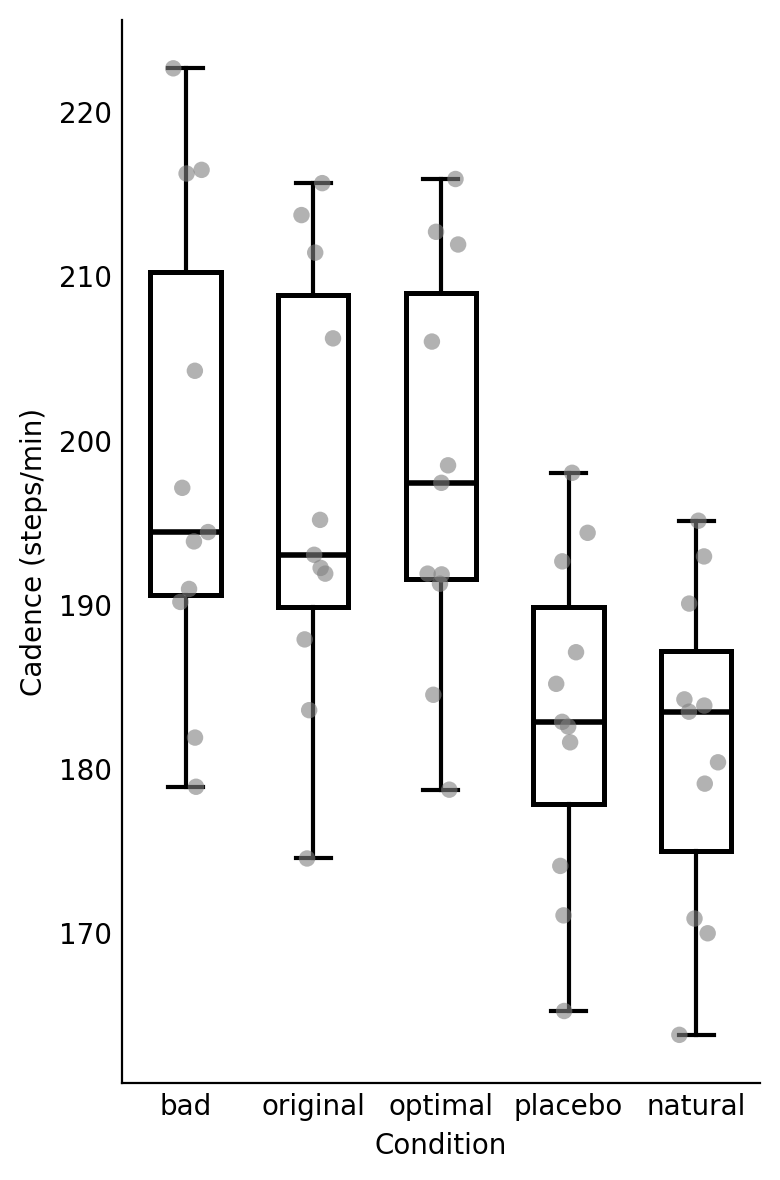

In [30]:
from collections import defaultdict

# Box + jittered scatter of cadences grouped by condition
conditions = ['bad', 'original', 'optimal', 'placebo', 'natural']
# group cadences by condition keyword using existing conditions list
cadence_groups = defaultdict(list)
for name, val in cadences.items():
    cond = next((c for c in conditions if c in name.lower()), None)
    if cond:
        cadence_groups[cond].append(val)

# prepare data/order
ordered_conds = [c for c in conditions if cadence_groups.get(c)]
data = [cadence_groups[c] for c in ordered_conds]
colors = [cond_colors.get(c, 'gray') for c in ordered_conds]

fig, ax = plt.subplots(figsize=(4, 6), dpi=200)

boxprops = dict(facecolor='none', edgecolor='black', linewidth=1.8)
medianprops = dict(linewidth=2, color='black')
whiskerprops = dict(linewidth=1.5, color='black')
capprops = dict(linewidth=1.5, color='black')

ax.boxplot(
    data,
    labels=ordered_conds,
    patch_artist=True,
    boxprops=boxprops,
    medianprops=medianprops,
    whiskerprops=whiskerprops,
    capprops=capprops,
    showfliers=False,
    widths=0.55,
    zorder=1,
)

# overlay jittered points
for i, (vals, col) in enumerate(zip(data, colors), start=1):
    x_j = np.random.normal(loc=i, scale=0.07, size=len(vals))
    ax.scatter(x_j, vals, color=col, alpha=0.6, s=35, edgecolors='none', zorder=2)

ax.set_ylabel('Cadence (steps/min)')
ax.set_xlabel('Condition')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='both', length=0)
plt.tight_layout()
plt.show()

In [7]:
# Cadence deltas per subject: (condition - natural)
cadence_deltas = {}
for subj in {k.split('_')[0] for k in cadences}:
    nat_key = f"{subj}_natural"
    if nat_key not in cadences:
        continue
    nat_val = cadences[nat_key]
    cadence_deltas[subj] = {}
    for cond in ['bad', 'placebo', 'original', 'optimal']:
        key = f"{subj}_{cond}"
        if key in cadences:
            cadence_deltas[subj][cond] = cadences[key] - nat_val

# flat view if needed
cadence_deltas_flat = {f"{s}_{c}": v for s, d in cadence_deltas.items() for c, v in d.items()}

print("Cadence deltas (condition - natural) by subject:")
for subj, diffs in cadence_deltas.items():
    print(subj, diffs)



Cadence deltas (condition - natural) by subject:
EPS9 {'bad': 11.860614790523755, 'placebo': 2.5171440096813456, 'original': 8.786962889103535, 'optimal': 12.181388487953456}
EPS3 {'bad': 12.88779505631581, 'placebo': -1.6561394765868727, 'original': 10.935675843455101, 'optimal': 14.258778984308293}
EPS12 {'bad': 13.45671164799495, 'placebo': 2.464799379550527, 'original': 11.493299996352391, 'optimal': 11.493299996352363}
EPS1 {'bad': 23.32582656370849, 'placebo': 1.4383911527741304, 'original': 18.50768640210572, 'optimal': 22.99224525061598}
EPS13 {'bad': 39.194173839023904, 'placebo': 3.6239485780770053, 'original': 32.2000359776938, 'optimal': 29.235346452248592}
EPS6 {'bad': 11.023979634260996, 'placebo': 0.19335378586711727, 'original': 12.693730271948567, 'optimal': 13.63142139951944}
EPS11 {'bad': 15.111917998946865, 'placebo': 1.4524172679131482, 'original': 10.743634525232096, 'optimal': 14.934697699346117}
EPS4 {'bad': 20.18481964536042, 'placebo': 4.10375742813801, 'origi

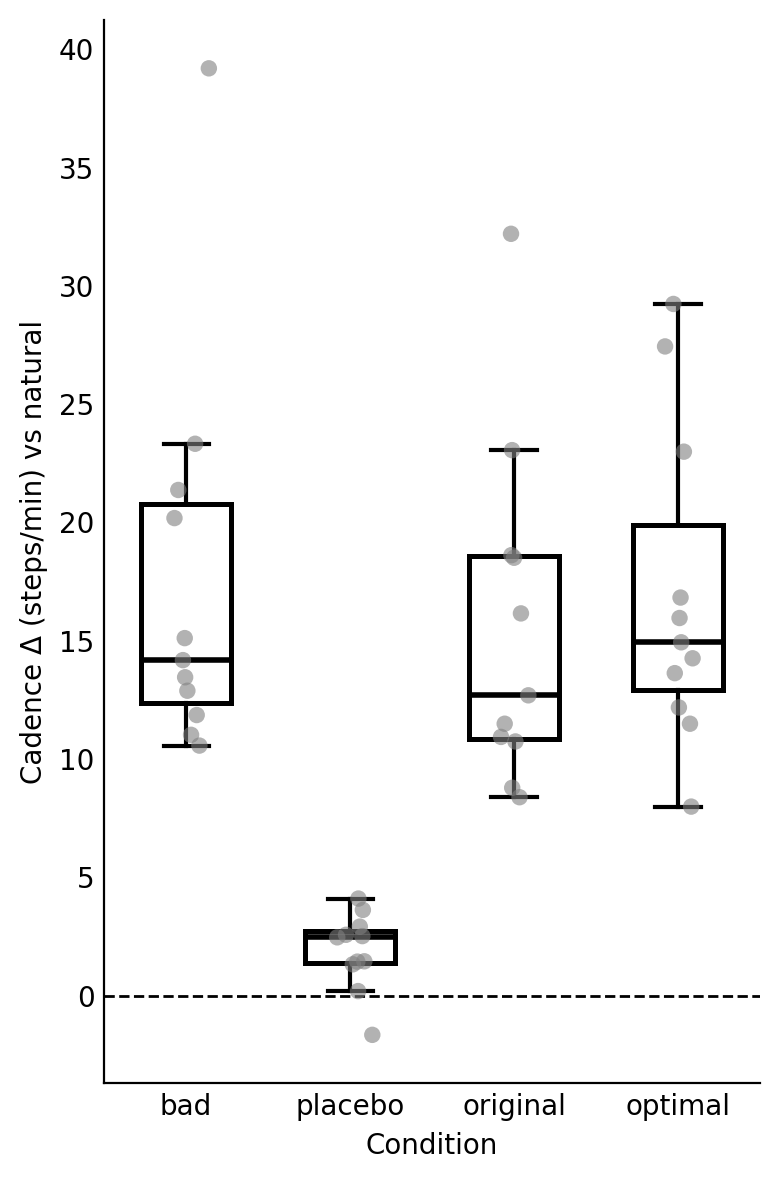

Condition-wise cadence delta stats (condition – natural):
bad: n=11, mean=17.561, std=8.384, median=14.181, min=10.569, max=39.194
placebo: n=11, mean=1.905, std=1.622, median=2.465, min=-1.656, max=4.104
original: n=11, mean=15.598, std=7.198, median=12.694, min=8.387, max=32.200
optimal: n=11, mean=16.995, std=6.735, median=14.935, min=7.990, max=29.235


In [8]:
from collections import defaultdict

# Visualize cadence deltas (condition – natural) grouped by condition

delta_groups = defaultdict(list)
for k, v in cadence_deltas_flat.items():
    for cond in ['bad', 'placebo', 'original', 'optimal']:
        if cond in k:
            delta_groups[cond].append(v)

order = ['bad', 'placebo', 'original', 'optimal']
data = [delta_groups[c] for c in order]
colors = [cond_colors.get(c, 'gray') for c in order]

fig, ax = plt.subplots(figsize=(4, 6), dpi=200)

bp = ax.boxplot(
    data,
    labels=order,
    patch_artist=True,
    boxprops=boxprops,
    medianprops=medianprops,
    whiskerprops=whiskerprops,
    capprops=capprops,
    showfliers=False,
    widths=0.55,
    zorder=1,
)

# overlay jittered points
for i, (vals, col) in enumerate(zip(data, colors), start=1):
    if not vals:
        continue
    xj = np.random.normal(loc=i, scale=0.07, size=len(vals))
    ax.scatter(xj, vals, color=col, alpha=0.6, s=35, edgecolors='none', zorder=2)

ax.axhline(0, color='black', linewidth=1, linestyle='--', zorder=0)
ax.set_ylabel('Cadence Δ (steps/min) vs natural')
ax.set_xlabel('Condition')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='both', length=0)
plt.tight_layout()
plt.show()

# Basic stats of cadence deltas averaged across subjects per condition
cond_stats = {}
for c in order:
    vals = delta_groups.get(c, [])
    if not vals:
        cond_stats[c] = {'n': 0, 'mean': np.nan, 'std': np.nan, 'median': np.nan, 'min': np.nan, 'max': np.nan}
        continue
    arr = np.asarray(vals, dtype=float)
    n = arr.size
    cond_stats[c] = {
        'n': n,
        'mean': float(arr.mean()),
        'std': float(arr.std(ddof=1)) if n > 1 else 0.0,
        'median': float(np.median(arr)),
        'min': float(arr.min()),
        'max': float(arr.max())
    }

print("Condition-wise cadence delta stats (condition – natural):")
for c in order:
    s = cond_stats[c]
    print(f"{c}: n={s['n']}, mean={s['mean']:.3f}, std={s['std']:.3f}, median={s['median']:.3f}, min={s['min']:.3f}, max={s['max']:.3f}")

# Overall stats across all deltas if all_vals is available
try:
    arr_all = np.asarray(all_vals, dtype=float)
    n_all = arr_all.size
    print("\nOverall (all conditions) cadence delta stats:")
    print(f"n={n_all}, mean={arr_all.mean():.3f}, std={(arr_all.std(ddof=1) if n_all > 1 else 0.0):.3f}, "
          f"median={np.median(arr_all):.3f}, min={arr_all.min():.3f}, max={arr_all.max():.3f}")
except NameError:
    pass

In [9]:
import numpy as np

# now we want to do an average +/- std for the cycles in each trial, save it into a new dictionary, and also plot it. 
import matplotlib.pyplot as plt

# Compute mean and std for cycles in each trial
trial_cycle_stats = {}

for trial_name, cycles in trial_cycles.items():
    # Get all cycle_distance arrays for this trial
    cycle_arrays = [c['cycle_distance'] for c in cycles if len(c['cycle_distance']) > 0]
    if not cycle_arrays:
        continue
    # Find minimum length to align cycles
    min_len = min([len(arr) for arr in cycle_arrays])
    # Stack and compute mean/std
    cycle_stack = np.stack([arr[:min_len] for arr in cycle_arrays])
    mean_cycle = np.nanmean(cycle_stack, axis=0)
    std_cycle = np.nanstd(cycle_stack, axis=0)
    trial_cycle_stats[trial_name] = {
        'mean': mean_cycle,
        'std': std_cycle,
        'n_cycles': len(cycle_arrays)
    }

    # # Plot mean ± std for this trial
    # x = np.arange(min_len)
    # plt.figure(figsize=(8, 4))
    # plt.plot(x, mean_cycle, label='Mean Cycle', color=get_color(trial_name))
    # plt.fill_between(x, mean_cycle - std_cycle, mean_cycle + std_cycle, color=get_color(trial_name), alpha=0.3, label='Std')
    # plt.title(f"Average Cycle ± Std for {trial_name}")
    # plt.xlabel("Frame (within cycle)")
    # plt.ylabel("Distance between markers")
    # plt.legend()
    # plt.tight_layout()
    # plt.show()

In [10]:
# go through and get the average peak values for each of the different conditions and subjects. 
averageDistances = {}
for key, value in experimentDistances.items():
    # find the peaks in the distance data
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(value, height=0)
    peak_values = value[peaks]
    if len(peak_values) > 0:
        average_peak = sum(peak_values) / len(peak_values)
    else:
        average_peak = 0
    averageDistances[key] = average_peak

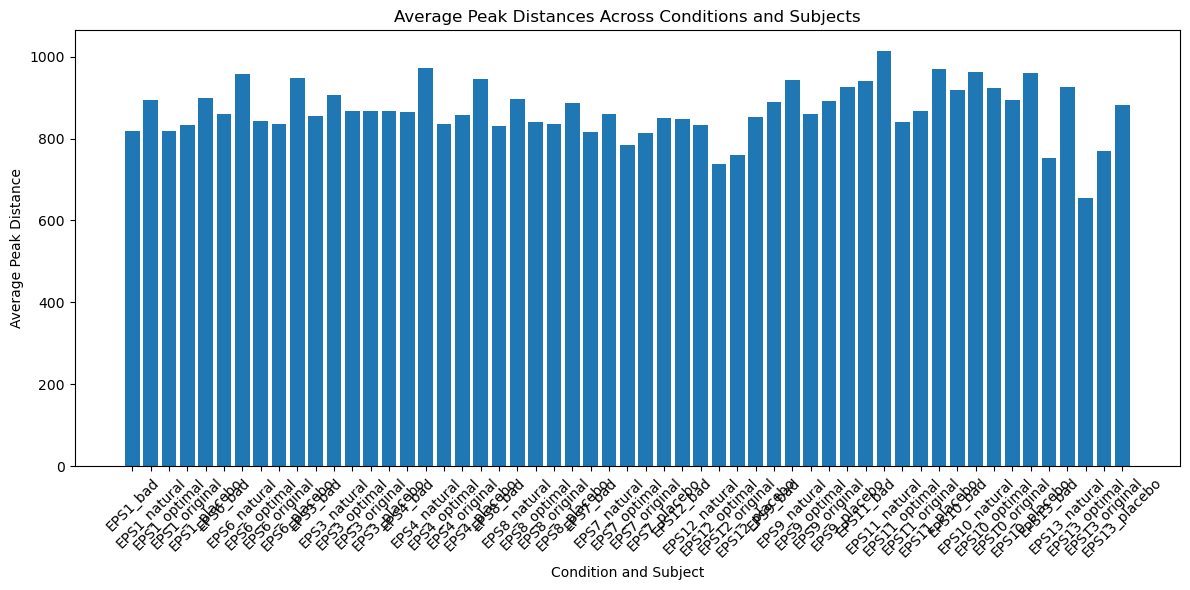

In [11]:
# create a bar chart of the average peak distances. 
plt.figure(figsize=(12, 6))
plt.bar(averageDistances.keys(), averageDistances.values())
plt.xlabel('Condition and Subject')
plt.ylabel('Average Peak Distance')
plt.title('Average Peak Distances Across Conditions and Subjects')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
##############################
# stiffness parameters for various exos - N/cm

# original - medium
k_band_1_og = 32.3 * 100

# bad - short+stiff 
k_band_1_bad = 36.6 * 100

# optimal - long+stiff
k_band_1_optimal = 89.7 * 100

# placebo - long+compliant
k_band_1_placebo = 10.4 * 100


##############################
# lengths for the various subjects - cm
subjectExos = {
    'EPS1_bad': 13.4,
    'EPS1_original': 21.25-1.5,
    'EPS1_optimal': 38.8,
    'EPS1_placebo': 38.8,
    
    'EPS3_bad': 14.4,
    'EPS3_original': 22.9-1.5,
    'EPS3_optimal': 41.8,
    'EPS3_placebo': 41.8,
    
    'EPS4_bad': 14.5,
    'EPS4_original': 23.0-1.5,
    'EPS4_optimal': 42.0,
    'EPS4_placebo': 42.0,
    
    'EPS6_bad': 14.5,
    'EPS6_original': 23-1.5,
    'EPS6_optimal': 42.0,
    'EPS6_placebo': 42.0,
    
    'EPS7_bad': 13.2,
    'EPS7_original': 21.0-1.5,
    'EPS7_optimal': 38.3,
    'EPS7_placebo': 38.3,
    
    'EPS8_bad': 15.8,
    'EPS8_original': 25-1.5,
    'EPS8_optimal': 45.7,
    'EPS8_placebo': 45.7,
    
    'EPS9_bad': 15.6,
    'EPS9_original': 24.8-1.5,
    'EPS9_optimal': 45.2,
    'EPS9_placebo': 45.2,
    
    'EPS10_bad': 15.9,
    'EPS10_original': 25.3-1.5,
    'EPS10_optimal': 46.1,
    'EPS10_placebo': 46.1,
    
    'EPS11_bad': 15.3,
    'EPS11_original': 24.25-1.5,
    'EPS11_optimal': 44.3,
    'EPS11_placebo': 44.3,
    
    'EPS12_bad': 13.7,
    'EPS12_original': 21.8-1.5,
    'EPS12_optimal': 39.7,
    'EPS12_placebo': 39.7,
    
    'EPS13_bad': 14.5,
    'EPS13_original': 23-1.5,
    'EPS13_optimal': 42.0,
    'EPS13_placebo': 42.0
}
# convert to meters
subjectExos = {k: v / 100 for k, v in subjectExos.items()}


In [13]:
# okay now compute spring total stiffnesses based on the lengths and stiffnesses of 1 cm sections
subjectExosStiffness = {}
for key, length in subjectExos.items():
    if 'bad' in key:
        k = k_band_1_bad
    elif 'optimal' in key:
        k = k_band_1_optimal
    elif 'original' in key:
        k = k_band_1_og
    elif 'placebo' in key:
        k = k_band_1_placebo
    else:
        k = None
    if k is not None:
        subjectExosStiffness[key] = k / (length * 100)

In [14]:
# print out subjectexosstiness in N/m
for key, value in subjectExosStiffness.items():
    print(f"{key}: stiffness = {value} N/m")

EPS1_bad: stiffness = 273.13432835820896 N/m
EPS1_original: stiffness = 163.54430379746833 N/m
EPS1_optimal: stiffness = 231.18556701030928 N/m
EPS1_placebo: stiffness = 26.804123711340207 N/m
EPS3_bad: stiffness = 254.16666666666663 N/m
EPS3_original: stiffness = 150.93457943925233 N/m
EPS3_optimal: stiffness = 214.59330143540672 N/m
EPS3_placebo: stiffness = 24.880382775119617 N/m
EPS4_bad: stiffness = 252.4137931034483 N/m
EPS4_original: stiffness = 150.23255813953486 N/m
EPS4_optimal: stiffness = 213.57142857142858 N/m
EPS4_placebo: stiffness = 24.761904761904763 N/m
EPS6_bad: stiffness = 252.4137931034483 N/m
EPS6_original: stiffness = 150.23255813953486 N/m
EPS6_optimal: stiffness = 213.57142857142858 N/m
EPS6_placebo: stiffness = 24.761904761904763 N/m
EPS7_bad: stiffness = 277.27272727272725 N/m
EPS7_original: stiffness = 165.6410256410256 N/m
EPS7_optimal: stiffness = 234.20365535248044 N/m
EPS7_placebo: stiffness = 27.154046997389035 N/m
EPS8_bad: stiffness = 231.645569620253

In [15]:
# now compute the tension in each of the exotendons based on their stiffness, resting length, and average peak distance during the trial. 
subjectExosTension = {}
for key, avg_distance in averageDistances.items():
    # get the subject and condition from the key
    if key in subjectExosStiffness:
        k = subjectExosStiffness[key]
        rest_length = subjectExos[key]
        stretch = (avg_distance/1000) - rest_length # distance is in mm, convert to m
        if stretch < 0:
            stretch = 0
            print(f"Warning: negative stretch for {key}, setting to 0")
        tension = k * stretch  # convert to N
        subjectExosTension[key] = tension
    else:
        subjectExosTension[key] = None
        if 'atural' not in key:
            import pdb; pdb.set_trace()

# print out the tensions
print("\nExotendon Tensions (N):")
for key, value in subjectExosTension.items():
    if value is None:
        print(f"{key}: tension = N/A")  



Exotendon Tensions (N):
EPS1_natural: tension = N/A
EPS6_natural: tension = N/A
EPS3_natural: tension = N/A
EPS4_natural: tension = N/A
EPS8_natural: tension = N/A
EPS7_natural: tension = N/A
EPS12_natural: tension = N/A
EPS9_natural: tension = N/A
EPS11_natural: tension = N/A
EPS10_natural: tension = N/A
EPS13_natural: tension = N/A


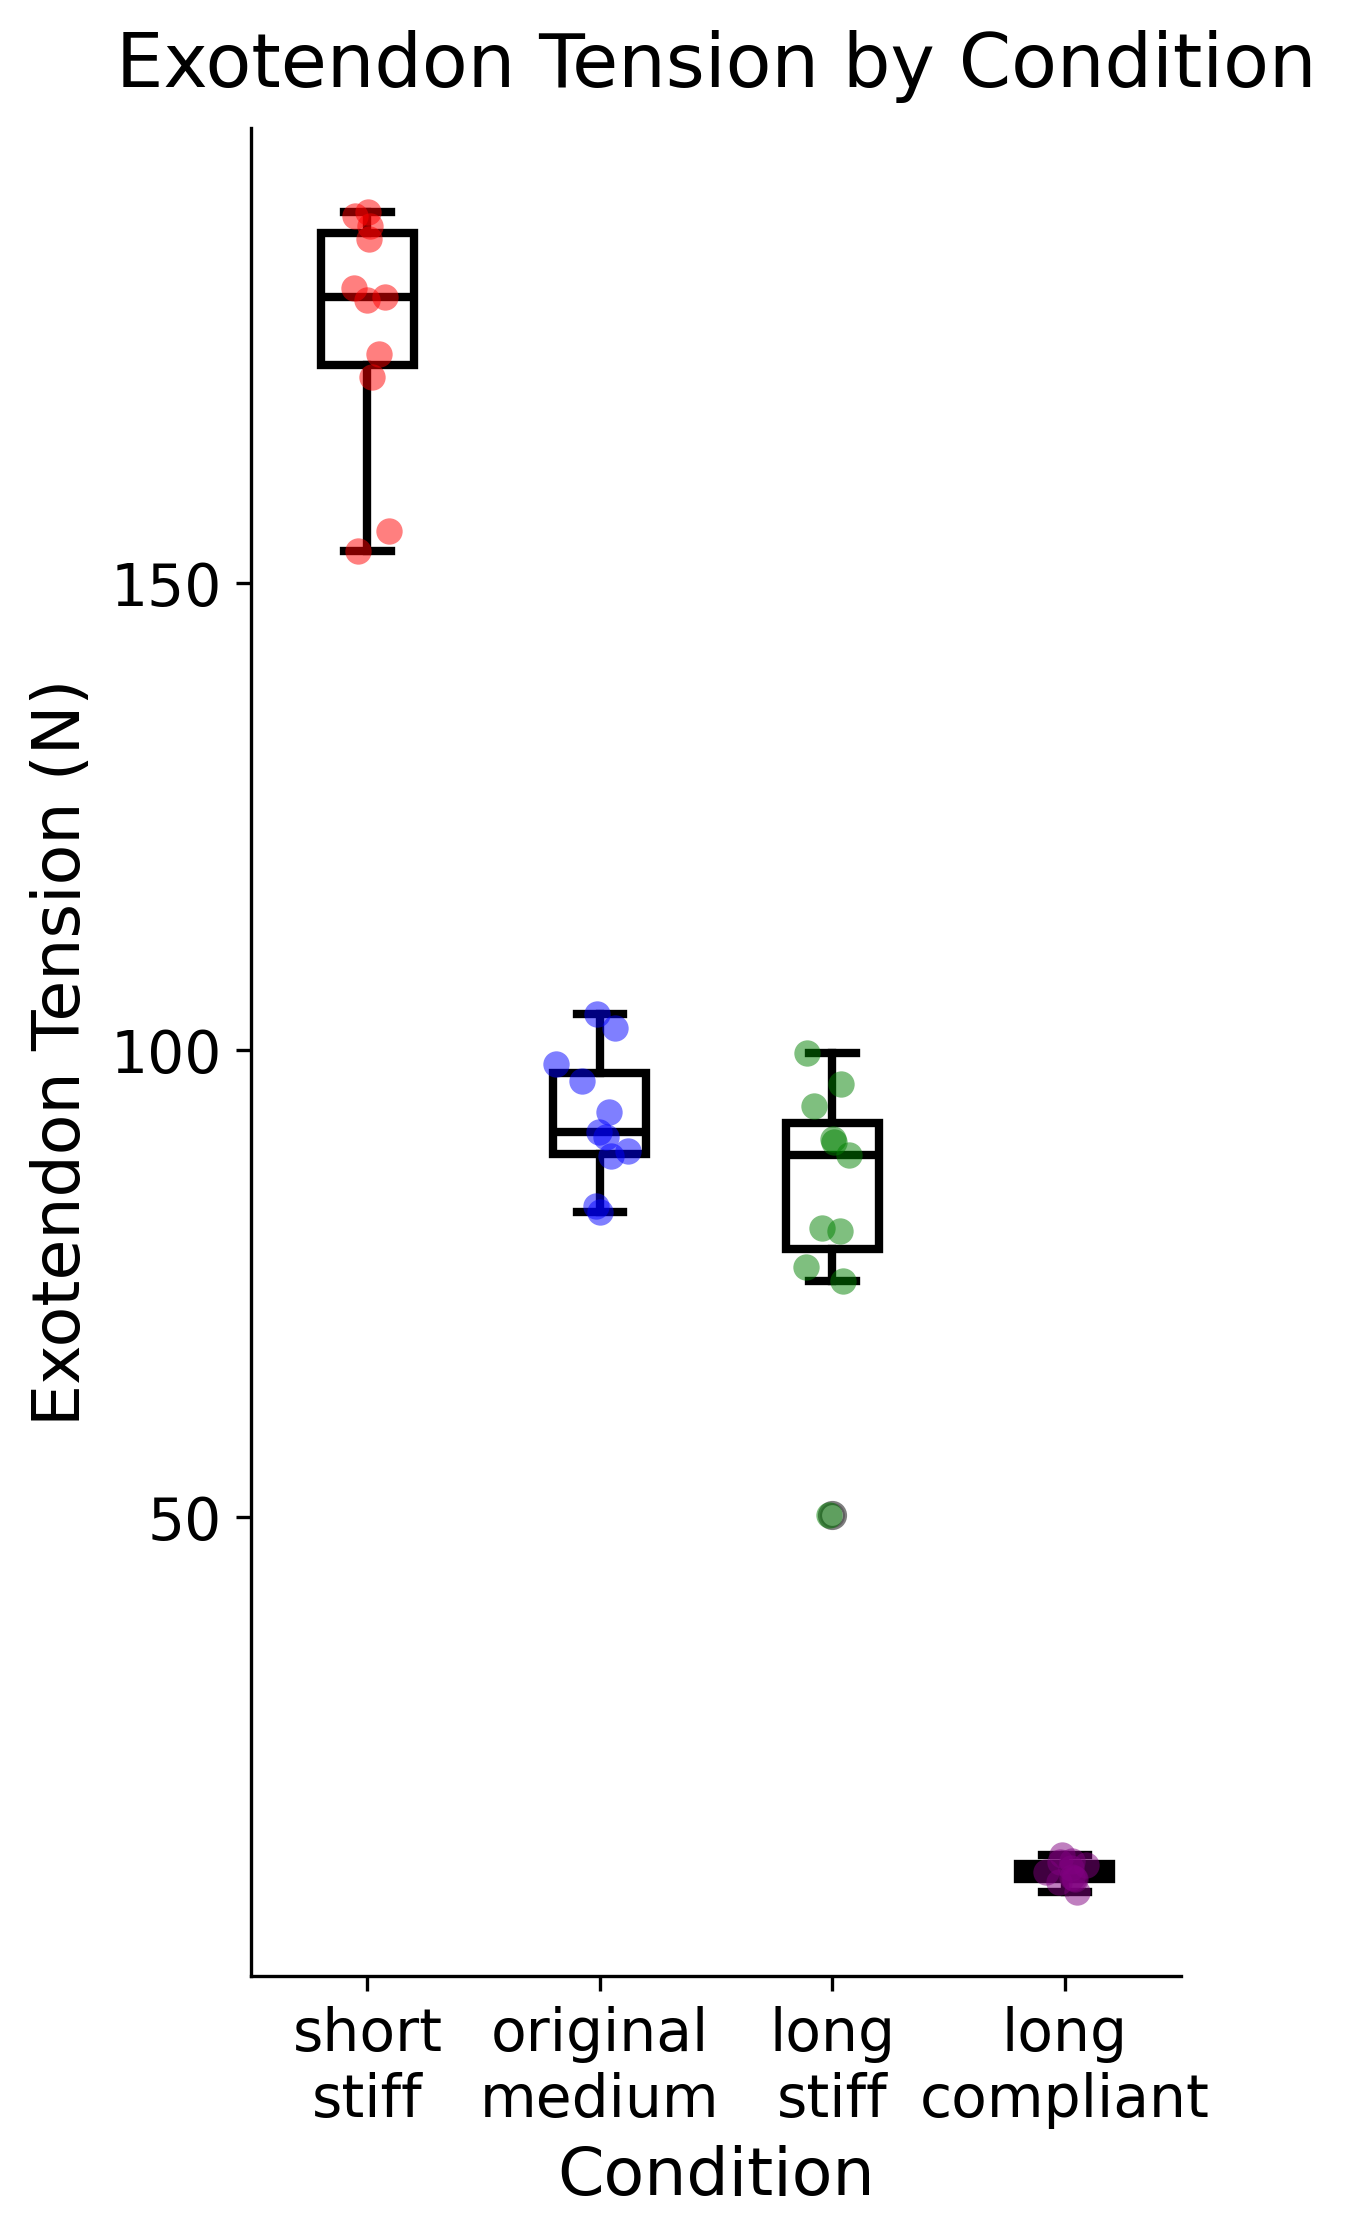

In [16]:
import numpy as np
# Prepare data grouped by condition
# Use line breaks in labels for better formatting
conditions = ['short-stiff', 'original-medium', 'long-stiff', 'long-compliant']
plot_labels = ['short\nstiff', 'original\nmedium', 'long\nstiff', 'long\ncompliant']
grouped_tensions = {cond: [] for cond in conditions}

# Map keys to conditions
for key, tension in subjectExosTension.items():
    if tension is not None:
        if 'bad' in key.lower():
            grouped_tensions['short-stiff'].append(tension)
        elif 'original' in key.lower():
            grouped_tensions['original-medium'].append(tension)
        elif 'optimal' in key.lower():
            grouped_tensions['long-stiff'].append(tension)
        elif 'placebo' in key.lower():
            grouped_tensions['long-compliant'].append(tension)

# Keep all boxes black, but color scatter points by condition

# Create boxplot with all-black boxes
fig, ax = plt.subplots(figsize=(4, 8), dpi=300)
data = [grouped_tensions[cond] for cond in conditions]
boxprops = dict(facecolor='none', edgecolor='black', linewidth=2)

box = ax.boxplot(
    data, 
    labels=plot_labels,
    patch_artist=True, 
    zorder=1, 
    boxprops=boxprops,
    medianprops=dict(linewidth=2, color='black'),
    whiskerprops=dict(linewidth=2, color='black'),
    capprops=dict(linewidth=2, color='black'),
    flierprops=dict(marker='o', markersize=6, linestyle='none', markerfacecolor='gray', alpha=0.5),
    widths=0.4
)

condition_colors = ['red', 'blue', 'green', 'purple']

# Set all boxes to black
for patch in box['boxes']:
    patch.set_facecolor('none')
    patch.set_edgecolor('black')
    patch.set_linewidth(2)

# Overlay individual points with jitter, colored by condition
for i, (cond, color) in enumerate(zip(conditions, condition_colors)):
    y = grouped_tensions[cond]
    x = np.random.normal(i + 1, 0.06, size=len(y))
    ax.scatter(
        x, y, alpha=0.5, 
        color=color,
        zorder=2, 
        s=40, 
        linewidth=0
    )

plt.rcParams['axes.axisbelow'] = True

ax.set_ylabel('Exotendon Tension (N)', fontsize=16)
ax.set_xlabel('Condition', fontsize=16)
ax.set_title('Exotendon Tension by Condition', fontsize=18, pad=10)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.locator_params(axis='y', nbins=6)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('G:\\Shared drives\\Exotendon\\predictiveSim\\analysis\\validationfigures\\experimentalExotendonTensions.png', dpi=300, bbox_inches='tight')
plt.show()



In [17]:
# Normalize trial-mean cycles per subject to a common length, convert distances -> tension, 
# then average across subjects per condition
resample_len = 1000
conditions = ['bad', 'original', 'optimal', 'placebo']
plot_colors = {
    'bad': 'red',
    'original': 'blue',
    'optimal': 'green',
    'placebo': 'purple'
}

# collect resampled tension cycles per condition (each entry ~ one subject/trial)
condition_subject_tensions = {c: [] for c in conditions}

for trial, stats in trial_cycle_stats.items():
    mean_cycle = stats.get('mean')   # mean cycle distance (mm)
    if mean_cycle is None:
        continue
    key = trial.lower()
    cond = None
    for c in conditions:
        if c in key:
            cond = c
            break
    if cond is None:
        continue

    # need stiffness (N/m) and rest length (m) for this trial
    if trial not in subjectExosStiffness or trial not in subjectExos:
        # skip if missing
        print(f"Skipping {trial}: missing stiffness/rest length")
        continue
    k = subjectExosStiffness[trial]    # N/m
    rest_length = subjectExos[trial]   # m

    # resample mean cycle (distance in mm) to common length
    src_x = np.linspace(0, 1, len(mean_cycle))
    tgt_x = np.linspace(0, 1, resample_len)
    resampled_dist_mm = np.interp(tgt_x, src_x, mean_cycle)

    # convert distance (mm -> m), compute stretch relative to rest length, clip negatives
    dist_m = resampled_dist_mm / 1000.0
    stretch = dist_m - rest_length
    stretch[stretch < 0] = 0.0

    # compute tension (N)
    tension = k * stretch

    condition_subject_tensions[cond].append(tension)

# compute across-subject mean and std for each condition and store results
condition_avg_stats_tension = {}
for c in conditions:
    arrs = condition_subject_tensions[c]
    if len(arrs) == 0:
        condition_avg_stats_tension[c] = {'mean': None, 'std': None, 'n': 0}
        continue
    stack = np.vstack(arrs)  # shape (n_subjects, resample_len)
    mean = np.nanmean(stack, axis=0)
    std = np.nanstd(stack, axis=0)
    condition_avg_stats_tension[c] = {'mean': mean, 'std': std, 'n': stack.shape[0]}

# quick print summary
for c in conditions:
    stats = condition_avg_stats_tension[c]
    print(f"{c}: n_subjects={stats['n']}  mean_len={(len(stats['mean']) if stats['mean'] is not None else 0)}")


bad: n_subjects=11  mean_len=1000
original: n_subjects=11  mean_len=1000
optimal: n_subjects=11  mean_len=1000
placebo: n_subjects=11  mean_len=1000


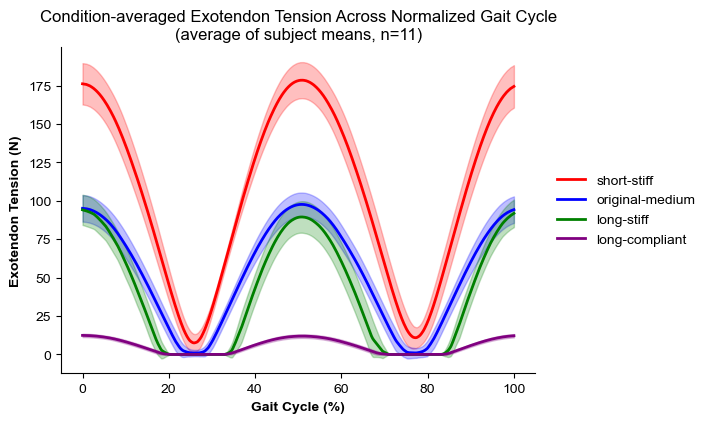

In [18]:
label_map = {
    'bad': 'short-stiff',
    'placebo': 'long-compliant',
    'optimal': 'long-stiff',
    'original': 'original-medium'
}

# plot mean ± std for each condition across normalized gait cycle (tension in N)
x_pct = np.linspace(0, 100, resample_len)
plt.figure(figsize=(10, 6))
for c in conditions:
    stats = condition_avg_stats_tension[c]
    if stats['mean'] is None:
        continue
    # label = f"{label_map.get(c, c)} (n={stats['n']})"
    label = f"{label_map.get(c, c)}"
    plt.plot(x_pct, stats['mean'], label=label, color=plot_colors[c], linewidth=2)
    plt.fill_between(x_pct, stats['mean'] - stats['std'], stats['mean'] + stats['std'],
                     color=plot_colors[c], alpha=0.25)

plt.xlabel('Gait Cycle (%)', fontweight='bold')
plt.ylabel('Exotendon Tension (N)', fontweight='bold')
plt.title('Condition-averaged Exotendon Tension Across Normalized Gait Cycle\n(average of subject means, n=11)')
ax = plt.gca()
# move legend outside to the right, centered vertically, and make room on the figure
leg = ax.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0.5, framealpha=1.0)
frame = leg.get_frame()
frame.set_facecolor('white')   # make legend background white
frame.set_edgecolor('none')    # remove border
plt.subplots_adjust(right=0.78)
# remove grid and hide top/right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
# publication-ready fonts/size and save high-resolution PNG + PDF
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Liberation Sans', 'Helvetica', 'Nimbus Sans L'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11
})
fig = plt.gcf()
fig.set_size_inches(6.5, 4.0)  # typical single-column width for journals (inches)
out_base = r'G:\Shared drives\Exotendon\predictiveSim\analysis\validationfigures\condition_avg_exotendon_tension'
fig.savefig(out_base + '.png', dpi=600, bbox_inches='tight', pad_inches=0.02)
plt.show()

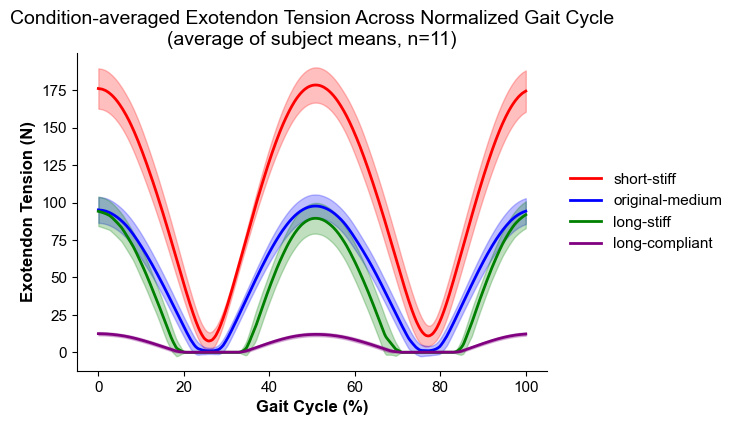

In [19]:
label_map = {
    'bad': 'short-stiff',
    'placebo': 'long-compliant',
    'optimal': 'long-stiff',
    'original': 'original-medium'
}

# plot mean ± std for each condition across normalized gait cycle (tension in N)
x_pct = np.linspace(0, 100, resample_len)
plt.figure(figsize=(10, 6))
for c in conditions:
    stats = condition_avg_stats_tension[c]
    if stats['mean'] is None:
        continue
    # label = f"{label_map.get(c, c)} (n={stats['n']})"
    label = f"{label_map.get(c, c)}"
    plt.plot(x_pct, stats['mean'], label=label, color=plot_colors[c], linewidth=2)
    plt.fill_between(x_pct, stats['mean'] - stats['std'], stats['mean'] + stats['std'],
                     color=plot_colors[c], alpha=0.25)

plt.xlabel('Gait Cycle (%)', fontweight='bold')
plt.ylabel('Exotendon Tension (N)', fontweight='bold')
plt.title('Condition-averaged Exotendon Tension Across Normalized Gait Cycle\n(average of subject means, n=11)')
ax = plt.gca()
# move legend outside to the right, centered vertically, and make room on the figure
leg = ax.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0.5, framealpha=1.0)
frame = leg.get_frame()
frame.set_facecolor('white')   # make legend background white
frame.set_edgecolor('none')    # remove border
plt.subplots_adjust(right=0.78)
# remove grid and hide top/right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
# publication-ready fonts/size and save high-resolution PNG + PDF
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Liberation Sans', 'Helvetica', 'Nimbus Sans L'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11
})
fig = plt.gcf()
fig.set_size_inches(6.5, 4.0)  # typical single-column width for journals (inches)
out_base = r'G:\Shared drives\Exotendon\predictiveSim\analysis\validationfigures\condition_avg_exotendon_tension'
fig.savefig(out_base + '.png', dpi=600, bbox_inches='tight', pad_inches=0.02)
plt.show()

In [20]:
import pickle
with open('G:\\Shared drives\\Exotendon\\predictiveSim\\analysis\\validationfigures\\exotendonTensionDataCompare.pkl', 'rb') as f:
    datacompare = pickle.load(f)
    

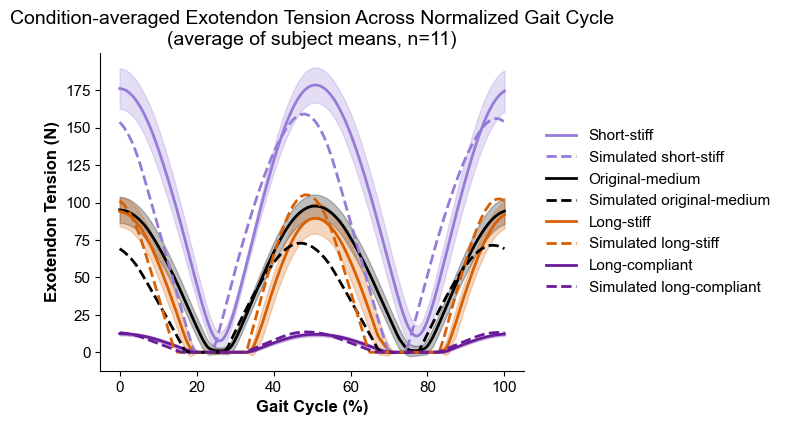

In [24]:
label_map = {
    'bad': 'Short-stiff',
    'placebo': 'Long-compliant',
    'optimal': 'Long-stiff',
    'original': 'Original-medium'
}
plot_colors = {
    'bad': "#967cd8",
    'original': 'black',
    'optimal': '#d95f02',
    'placebo': '#6A1B9A' # '#1b9e77'
}
# plot mean ± std for each condition across normalized gait cycle (tension in N)
resample_len = len(list(datacompare.values())[0])  # Get length from simulation data
x_pct = np.linspace(0, 100, resample_len)
plt.figure(figsize=(10, 6))
for c in conditions:
    stats = condition_avg_stats_tension[c]
    if stats['mean'] is None:
        continue
    # label = f"{label_map.get(c, c)} (n={stats['n']})"
    label = f"{label_map.get(c, c)}"
    plt.plot(x_pct, stats['mean'], label=label, color=plot_colors[c], linewidth=2)
    plt.fill_between(x_pct, stats['mean'] - stats['std'], stats['mean'] + stats['std'],
                     color=plot_colors[c], alpha=0.25)

simcolor = {
    'l = 0.1435 | k = 240': '#967cd8',
    'l = 0.2870 | k = 120': 'black',
    'l = 0.4305 | k = 240': '#d95f02',
    'l = 0.4305 | k = 30': '#6A1B9A' #'#1b9e77'
}
simlabels = {
    'l = 0.1435 | k = 240': 'Simulated short-stiff',
    'l = 0.2870 | k = 120': 'Simulated original-medium',
    'l = 0.4305 | k = 240': 'Simulated long-stiff',
    'l = 0.4305 | k = 30': 'Simulated long-compliant'
}
# for each in datacompare.keys():
#     plt.plot(x_pct, datacompare[each], label=simlabels.get(each, each), linestyle='--', linewidth=2, color=simcolor.get(each, 'black'))

plt.plot(x_pct, datacompare['l = 0.1435 | k = 240'], label='Simulated short-stiff', linestyle='--', linewidth=2, color='#967cd8')
plt.plot(x_pct, datacompare['l = 0.2870 | k = 120'], label='Simulated original-medium', linestyle='--', linewidth=2, color='black')
plt.plot(x_pct, datacompare['l = 0.4305 | k = 240'], label='Simulated long-stiff', linestyle='--', linewidth=2, color='#d95f02')
plt.plot(x_pct, datacompare['l = 0.4305 | k = 30'], label='Simulated long-compliant', linestyle='--', linewidth=2, color='#6A1B9A')#'#1b9e77')

plt.xlabel('Gait Cycle (%)', fontweight='bold')
plt.ylabel('Exotendon Tension (N)', fontweight='bold')
plt.title('Condition-averaged Exotendon Tension Across Normalized Gait Cycle\n(average of subject means, n=11)')
ax = plt.gca()
# move legend outside to the right, centered vertically, and make room on the figure
leg = ax.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0.5, framealpha=1.0)
frame = leg.get_frame()
frame.set_facecolor('white')   # make legend background white
frame.set_edgecolor('none')    # remove border
plt.subplots_adjust(right=0.78)
# remove grid and hide top/right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
# publication-ready fonts/size and save high-resolution PNG + PDF
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Liberation Sans', 'Helvetica', 'Nimbus Sans L'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11
})
fig = plt.gcf()
fig.set_size_inches(6.5, 4.0)  # typical single-column width for journals (inches)

# Get current handles and labels
handles, labels = ax.get_legend_handles_labels()

# Define desired order (experimental and simulated alternating)
desired_order = [
    'Short-stiff',
    'Simulated short-stiff',
    'Original-medium',
    'Simulated original-medium',
    'Long-stiff',
    'Simulated long-stiff',
    'Long-compliant',
    'Simulated long-compliant'
]

# Reorder handles and labels
ordered_handles = []
ordered_labels = []
for label in desired_order:
    try:
        idx = labels.index(label)
        ordered_handles.append(handles[idx])
        ordered_labels.append(labels[idx])
    except ValueError:
        pass

# Redraw legend with new order
leg = ax.legend(ordered_handles, ordered_labels, bbox_to_anchor=(1.02, 0.5), 
          loc='center left', borderaxespad=0.5, framealpha=1.0)
frame = leg.get_frame()
frame.set_facecolor('white')   # make legend background white
frame.set_edgecolor('none')    # remove border
out_base = r'G:\Shared drives\Exotendon\predictiveSim\analysis\validationfigures\condition_avg_exotendon_tension'
fig.savefig(out_base + '.png', dpi=600, bbox_inches='tight', pad_inches=0.02)
plt.show()

In [51]:
# find the peak average tension for each of the experimental conditions
peak_tensions = {}
std_at_peak = {}

for c in conditions:
    stats = condition_avg_stats_tension[c]
    if stats['mean'] is None:
        peak_tensions[c] = None
        std_at_peak[c] = None
        continue

    mean_curve = stats['mean']
    std_curve = stats['std']

    peak_idx = np.argmax(mean_curve)
    peak_tension = mean_curve[peak_idx]
    peak_std = std_curve[peak_idx] if std_curve is not None else None

    peak_tensions[c] = peak_tension
    std_at_peak[c] = peak_std

    print(f"{c}: peak average tension = {peak_tension:.3f} N, std at peak = {peak_std:.3f} N")


bad: peak average tension = 178.573 N, std at peak = 11.752 N
original: peak average tension = 97.701 N, std at peak = 7.703 N
optimal: peak average tension = 94.159 N, std at peak = 9.850 N
placebo: peak average tension = 12.429 N, std at peak = 1.093 N


Columns: ['Subject', 'Placebo', 'Bad', 'Original', 'Optimal']
  Subject   Placebo        Bad   Original    Optimal
0    EPS1 -2.876106 -12.094395 -14.306785  -7.448378
1    EPS3  3.808864  -5.678670  -4.362881 -12.811634
2    EPS4 -1.889169  -7.367758  -4.785894  -4.534005
3    EPS6  0.189633  -1.327434  -2.844501   1.201011
4    EPS7 -3.957947  -6.060606  -6.679035  -5.009276
Top 10 (highest):
EPS11_Optimal: 10.1488498
EPS11_Original: 8.795669824
EPS11_Placebo: 5.615696888
EPS10_Bad: 4.95923913
EPS11_Bad: 4.533152909
EPS8_Optimal: 4.316069057
EPS3_Placebo: 3.808864266
EPS6_Optimal: 1.201011378
EPS6_Placebo: 0.189633375
EPS9_Optimal: 0.138600139

Bottom 10 (lowest):
EPS1_Original: -14.30678466
EPS3_Optimal: -12.81163435
EPS1_Bad: -12.09439528
EPS12_Placebo: -11.16015132
EPS10_Original: -11.00543478
EPS8_Original: -10.82337317
EPS8_Bad: -8.565737052
EPS1_Optimal: -7.448377581
EPS4_Bad: -7.367758186
EPS7_Original: -6.67903525


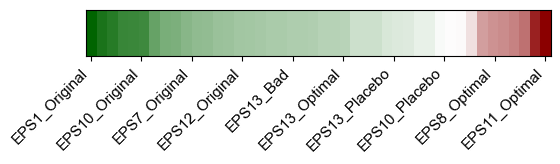

In [22]:
################################
# okay next is going to be to recreate the metabolic savings plots color coding by each subject/condition. 
# import from pandas clipboard: metabolicsData.xlsx
import pandas as pd
import numpy as np
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap, to_hex
metabolics_df = pd.read_excel('experimentMetabolics.xlsx')
# print(f"Loaded metabolics file: {file_path}")
print("Columns:", metabolics_df.columns.tolist())
print(metabolics_df.head())

# Flatten metabolics_df into a dict like "EPS1_placebo": value

cols = metabolics_df.columns
cols_lower = [c.lower() for c in cols]

subject_col = None
condition_col = None
for c, cl in zip(cols, cols_lower):
    if 'subject' in cl or 'participant' in cl or cl == 'id':
        subject_col = c
    if 'condition' in cl or 'cond' in cl or 'trial' in cl:
        condition_col = c

metabolics_flat = {}

if subject_col is not None and condition_col is not None:
    # wide table with explicit subject and condition columns + one value column
    value_cols = [c for c in cols if c not in (subject_col, condition_col)]
    if not value_cols:
        raise ValueError("Could not find a value column alongside subject/condition.")
    value_col = value_cols[0]
    for _, row in metabolics_df.iterrows():
        key = f"{row[subject_col]}_{row[condition_col]}"
        val = row[value_col]
        if pd.notna(val):
            metabolics_flat[key] = float(val)
elif subject_col is not None:
    # subject column + other columns are conditions (melt)
    melted = metabolics_df.melt(id_vars=[subject_col], var_name='condition', value_name='value')
    for _, r in melted.iterrows():
        if pd.notna(r['value']):
            metabolics_flat[f"{r[subject_col]}_{r['condition']}"] = float(r['value'])
else:
    # assume index is subject and columns are conditions (stack)
    df = metabolics_df.copy()
    # if index is numeric and a column contains subject-like strings, try to use that column instead
    stacked = df.stack(dropna=True)
    for (subj, cond), v in stacked.items():
        metabolics_flat[f"{subj}_{cond}"] = float(v)

# sort flattened metabolics by value
sorted_metabolics_asc = dict(sorted(metabolics_flat.items(), key=lambda kv: kv[1]))
sorted_metabolics_desc = dict(sorted(metabolics_flat.items(), key=lambda kv: kv[1], reverse=True))

# convenience: pandas Series (descending)
sorted_metabolics_series = pd.Series(sorted_metabolics_desc)

# print summary
print("Top 10 (highest):")
for k, v in list(sorted_metabolics_desc.items())[:10]:
    print(f"{k}: {v}")
print("\nBottom 10 (lowest):")
for k, v in list(sorted_metabolics_asc.items())[:10]:
    print(f"{k}: {v}")

import matplotlib.pyplot as plt

# values and keys in ascending order (most negative -> most positive)
keys_asc = list(sorted_metabolics_asc.keys())
vals_asc = np.array([sorted_metabolics_asc[k] for k in keys_asc], dtype=float)

minv = vals_asc.min()
maxv = vals_asc.max()

# build a diverging colormap that goes dark green -> white -> dark red
if minv < 0 and maxv > 0:
    cmap = LinearSegmentedColormap.from_list('green_white_red', ['darkgreen', 'white', 'darkred'])
    norm = TwoSlopeNorm(vmin=minv, vcenter=0.0, vmax=maxv)
elif maxv <= 0:
    # all values non-positive: map dark green -> white
    cmap = LinearSegmentedColormap.from_list('green_white', ['darkgreen', 'white'])
    norm = plt.Normalize(vmin=minv, vmax=maxv)
else:
    # all values non-negative: map white -> dark red
    cmap = LinearSegmentedColormap.from_list('white_red', ['white', 'darkred'])
    norm = plt.Normalize(vmin=minv, vmax=maxv)

# color mapping for each label (keys)
metabolics_color_map = {k: to_hex(cmap(norm(v))) for k, v in zip(keys_asc, vals_asc)}

# also provide a list of colors in ascending order (matches keys_asc)
metabolics_colors_asc = [metabolics_color_map[k] for k in keys_asc]

# optional: display a small legend example (uncomment to show)
fig, ax = plt.subplots(figsize=(6, 0.6))
# pass the 2D array directly (shape (1, n)), don't wrap it in a list which adds an extra dimension
ax.imshow(vals_asc.reshape(1, -1), cmap=cmap, norm=norm, aspect='auto')
ax.set_xticks(np.linspace(0, len(keys_asc)-1, min(10, len(keys_asc))))
ax.set_xticklabels([keys_asc[int(i)] for i in np.linspace(0, len(keys_asc)-1, min(10, len(keys_asc))).astype(int)], rotation=45, ha='right')
ax.yaxis.set_visible(False)
plt.show()



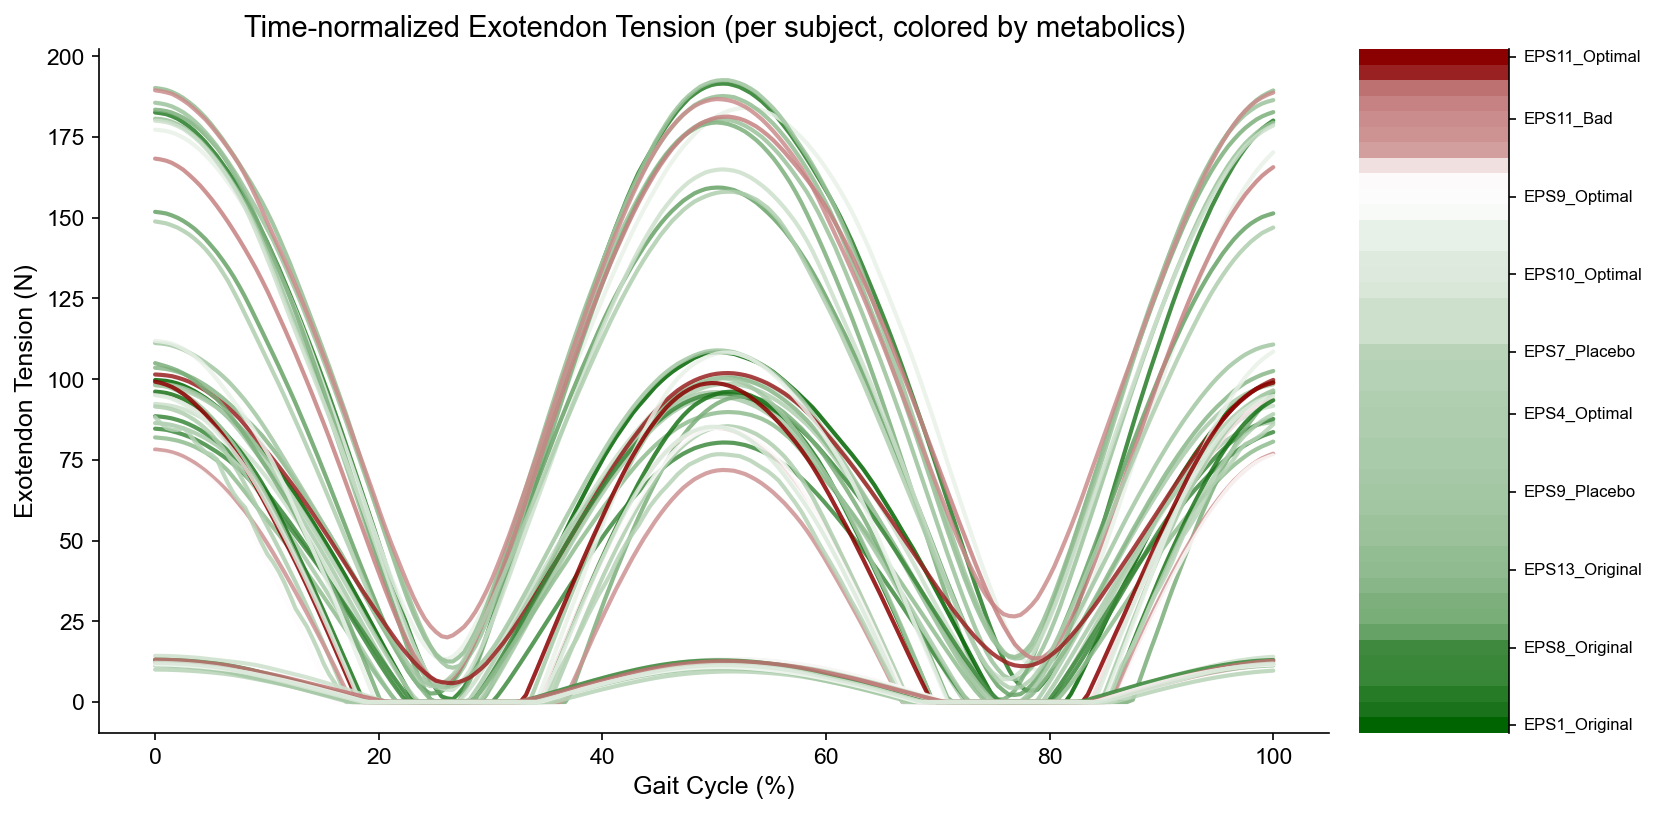

In [21]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 6), dpi=150)
# plot time-normalized tension curves per subject/condition using metabolics_color_map
try:
    x_axis = x_pct
except NameError:
    try:
        n = resample_len
    except NameError:
        n = 200
    x_axis = np.linspace(0, 100, n)

target_len = len(x_axis)

# case-insensitive metabolics color lookup
met_colormap_ci = {}
try:
    met_colormap_ci = {k.lower(): v for k, v in metabolics_color_map.items()}
except NameError:
    met_colormap_ci = {}

# reconstruct trial order per condition to align with condition_subject_tensions append order
trials_by_cond = {c: [] for c in conditions}
for t in trial_cycle_stats.keys():
    tl = t.lower()
    cond = next((c for c in conditions if c in tl), None)
    if cond is None:
        continue
    stats = trial_cycle_stats[t]
    if stats.get('mean') is None:
        continue
    try:
        if t not in subjectExosStiffness or t not in subjectExos:
            continue
    except NameError:
        pass
    trials_by_cond[cond].append(t)

for c in conditions:
    arrs = condition_subject_tensions.get(c, [])
    trials = trials_by_cond.get(c, [])
    if not arrs:
        continue

    for i, curve in enumerate(arrs):
        if curve is None:
            continue
        y = np.asarray(curve, dtype=float).ravel()
        if y.size == 0:
            continue
        if y.size != target_len:
            src = np.linspace(0.0, 1.0, y.size)
            tgt = np.linspace(0.0, 1.0, target_len)
            y = np.interp(tgt, src, y)

        tname = trials[i] if i < len(trials) else None
        color = met_colormap_ci.get(tname.lower(), None) if tname else None
        if color is None:
            color = plot_colors.get(c, 'gray')

        ax[0].plot(
            x_axis, y,
            color=color,
            alpha=0.85,
            linewidth=2.0,
            solid_capstyle='round',
            solid_joinstyle='round',
            antialiased=True,
            zorder=3
        )

ax[0].set_xlabel('Gait Cycle (%)')
ax[0].set_ylabel('Exotendon Tension (N)')
ax[0].set_title('Time-normalized Exotendon Tension (per subject, colored by metabolics)')
ax[0].spines['right'].set_visible(False)
ax[0].spines['top'].set_visible(False)



# make the left subplot much wider than the right one by repositioning axes
left = 0.03
bottom = 0.12
height = 0.76
gap = 0.02
width1 = 0.10  # narrow right subplot
# leave a small right margin (0.03) and compute main width to fill remaining space
width0 = 1.0 - left - width1 - gap - 0.03
ax[0].set_position([left, bottom, width0, height])
ax[1].set_position([left + width0 + gap, bottom, width1, height])

# Prevent the later plt.tight_layout() call from undoing these manual positions
# by overriding the figure's tight_layout method (safe in a notebook session).
fig.tight_layout = lambda *a, **k: None

# show a vertical color strip (one column) and labels along y-axis (reversed order)
ax[1].axis('on')  # re-enable axis so ticks/labels can be shown

# display reversed colormap so the order is top-to-bottom reversed
ax[1].imshow(vals_asc[::-1].reshape(-1, 1), cmap=cmap, norm=norm, aspect='auto')

n_ticks = min(10, len(keys_asc))
ytick_pos = np.linspace(0, len(keys_asc) - 1, n_ticks).astype(int)
# use reversed keys to match the displayed (reversed) color strip
ax[1].set_yticks(ytick_pos)
ax[1].set_yticklabels([keys_asc[::-1][i] for i in ytick_pos], rotation=0, va='center', fontsize=8)

# hide x-axis ticks/labels (we only want the vertical map)
ax[1].set_xticks([])
ax[1].xaxis.set_visible(False)

# position ticks on the right side of the narrow strip and hide unnecessary spines
ax[1].yaxis.set_ticks_position('right')
ax[1].yaxis.set_label_position('right')
for spine in ['left', 'top', 'bottom']:
    ax[1].spines[spine].set_visible(False)
plt.savefig('G:\\Shared drives\\Exotendon\\predictiveSim\\analysis\\validationfigures\\time_normalized_exotendon_tension_colored_by_metabolics.png', dpi=300, bbox_inches='tight')
plt.show()

## Working on the 5k stuff here 

In [57]:
# import from clipboard to dataframe: experimentMetabolics.xlsx –> 5ks sheet, delta table. 
import os

race_df = pd.read_csv('5kDifferences.csv')
print(race_df.head())

   Time  HR  Cadence
0   -11   1       23
1    31 -11       24
2     3  -5       28
3    -5  -1       11
4   -20  -2       13


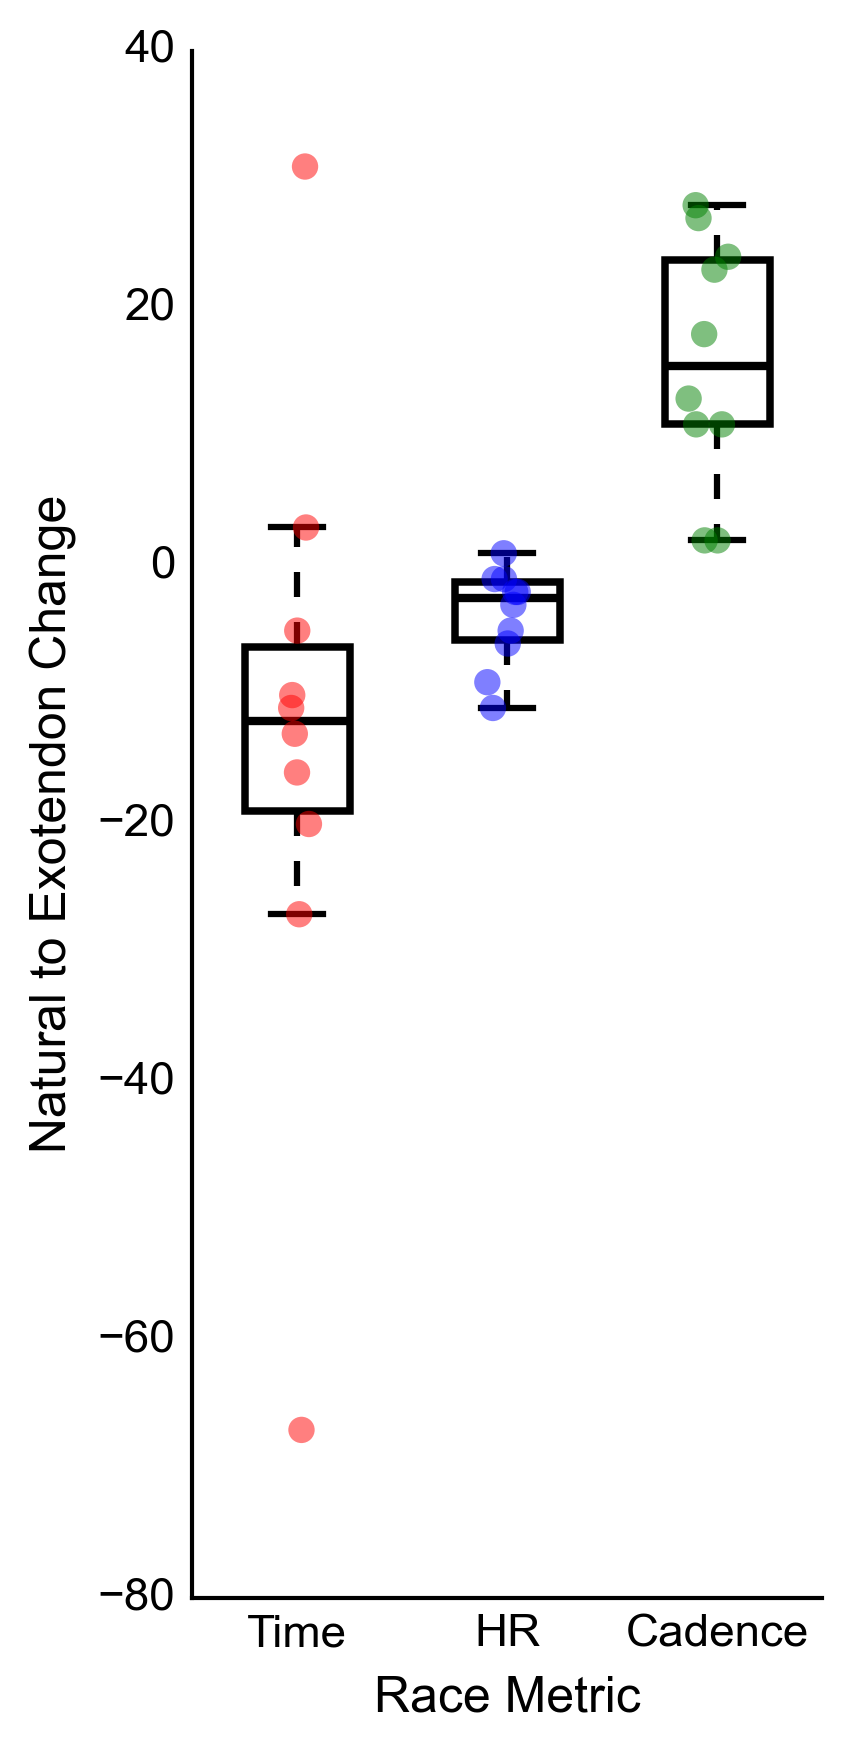

In [58]:
# Box-and-jitter plot for up to three columns from race_df (uses existing race_df, np, plt)
# Select numeric columns (use first 3 if more exist)
numeric_cols = race_df.select_dtypes(include=[np.number]).columns.tolist()
if not numeric_cols:
    raise ValueError("race_df contains no numeric columns to plot.")
cols = numeric_cols[:3]

data = [race_df[c].dropna().values for c in cols]
colors = ['red', 'blue', 'green'][:len(cols)]

fig, ax = plt.subplots(figsize=(3, 6), dpi=300)

# remove grey background: set figure and axes facecolors to white
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Boxplot with black boxes
boxprops = dict(facecolor='none', edgecolor='black', linewidth=1.8)
medianprops = dict(linewidth=2, color='black')
whiskerprops = dict(linewidth=1.5, color='black')
capprops = dict(linewidth=1.5, color='black')

bp = ax.boxplot(
    data,
    labels=cols,
    patch_artist=True,
    boxprops=boxprops,
    medianprops=medianprops,
    whiskerprops=whiskerprops,
    capprops=capprops,
    widths=0.5,
    showfliers=False,
    zorder=1
)

# Overlay individual points with jitter, colored per column
for i, (y, color) in enumerate(zip(data, colors)):
    if len(y) == 0:
        continue
    x_jitter = np.random.normal(loc=(i + 1), scale=0.06, size=len(y))
    ax.scatter(x_jitter, y, color=color, alpha=0.5, s=40, edgecolors='None', linewidths=0.4, zorder=2)

ax.set_xlabel('Race Metric')
ax.set_ylabel('Natural to Exotendon Change')
# ax.set_title('Race differences: boxplot with individual points (jittered)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# remove tick marks but keep tick labels
ax.tick_params(axis='both', which='both', length=0)   # remove tick tick marks
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
ax.minorticks_off()

# ensure no grid and white background when saving/displaying
ax.grid(False)
plt.tight_layout()
plt.savefig('G:\\Shared drives\\Exotendon\\predictiveSim\\analysis\\validationfigures\\race_differences_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()